# Models to Predict Cost Deviation Risk

Preguntas de investigación del artículo:
1. ¿Qué tan precisas pueden ser predicciones de las desviacione en tiempo y costo en proyectos de infraestructura?
2. ¿Que tan relevantes pueden ser los diferentes grupos de variables del proyecto: características del proyecto y el proceso de contratación, indicadores de desempeño de la entidad, indicadores de desempeño del contratista, y variablex exogenas?
3. Caules son las principales características del proyecto que determinan las desviaciones
4. Caules son los principales indicadores de la entidad para determinar proyecto que determinan las desviaciones
5. Caules son los principales indicadores del contratista para determinar proyecto que determinan las desviaciones
6. Caules son las principales variables exogenas para determinar proyecto que determinan las desviaciones

In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# Import data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
#from transformData import dataCleaning
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore", category=FutureWarning)

In [10]:
# Data Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from yellowbrick.model_selection import FeatureImportances

# Model Selection & Validation
from sklearn.model_selection import train_test_split, cross_val_score

# Cross validation and hyperparameters
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

# Pipeline & Imbalanced Data Handling
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Model Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
    RocCurveDisplay
)

# Feature Analysis
from sklearn.inspection import permutation_importance

# Natural Language Processing
import nltk

In [11]:
# Configurar conexion con google drive y con carpeta de google colab
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Colab Notebooks/Prediccion de Adiciones Proyectos de Infraestructura')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
df = pd.read_csv('Data/trainData.csv')   # Load the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27905 entries, 0 to 27904
Data columns (total 51 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   contractValueMw(G1)                    27905 non-null  float64
 1   contractDurationDays(G1)               27905 non-null  float64
 2   projectIntensityMw(G1)                 27905 non-null  float64
 3   workCategory(G1)                       27905 non-null  object 
 4   tenderValueMw(G2)                      27905 non-null  float64
 5   bidContractRatio(G2)                   27905 non-null  float64
 6   contractMethodType(G2)                 27905 non-null  object 
 7   contractMonthSigned(G2)                27905 non-null  int64  
 8   contractMonthStart(G2)                 27905 non-null  int64  
 9   electoralYear(G2)                      27905 non-null  int64  
 10  preelectoralYear(G2)                   27905 non-null  int64  
 11  da

In [13]:
# Load list of columns
with open('Data/projectsColumns.txt', 'r') as f:
    projectsColumns = f.read().splitlines()
with open('Data/contractColumns.txt', 'r') as f:
    contractColumns = f.read().splitlines()
with open('Data/buyerColumns.txt', 'r') as f:
    buyerColumns = f.read().splitlines()
with open('Data/supplierColumns.txt', 'r') as f:
    supplierColumns = f.read().splitlines()
with open('Data/buyerIndicatorsColumns.txt', 'r') as f:
    buyerIndicators = f.read().splitlines()
with open('Data/terridataColumns.txt', 'r') as f:
    terridataColumns = f.read().splitlines()
with open('Data/outcomeColumns.txt', 'r') as f:
    outcomeColumns = f.read().splitlines()

In [14]:
# convert contractMonthSigned(G2) and contractMonthStart(G2) to object
df['contractMonthSigned(G2)'] = df['contractMonthSigned(G2)'].astype(str)
df['contractMonthStart(G2)'] = df['contractMonthStart(G2)'].astype(str)

### Funciones

In [15]:
def create_preprocessing_pipeline(numeric_columns, categorical_columns,
                                 num_strategy='median', cat_strategy='most_frequent'):
    """
    Crea un pipeline de preprocesamiento para características numéricas y categóricas.

    Parámetros:
    -----------
    numeric_columns : list
        Lista de nombres de columnas numéricas
    categorical_columns : list
        Lista de nombres de columnas categóricas
    num_strategy : str, opcional
        Estrategia de imputación para columnas numéricas (default: 'median')
    cat_strategy : str, opcional
        Estrategia de imputación para columnas categóricas (default: 'most_frequent')

    Returns:
    --------
    ColumnTransformer
        Pipeline de preprocesamiento configurado
    """
    # Pipeline para columnas numéricas
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy=num_strategy, add_indicator=True)),  # Indicador para valores faltantes
        ('scaler', StandardScaler())  # Escalar después de imputar para evitar sesgos
    ])

    # Pipeline para columnas categóricas
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy=cat_strategy, add_indicator=True)),  # Indicador para valores faltantes
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # sparse_output=False para compatibilidad
    ])

    # Combinar transformaciones
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_columns),
            ('cat', categorical_transformer, categorical_columns)
        ],
        remainder='passthrough'  # Mantener otras columnas que no estén en las listas
    )

    return preprocessor

In [16]:
def evaluate_model(model, X_test, y_test):
    """
    Evalúa un modelo entrenado en el conjunto de prueba.

    Parámetros:
    -----------
    model : objeto estimador entrenado
        El modelo a evaluar
    X_test : array-like
        Características de prueba
    y_test : array-like
        Etiquetas reales de prueba

    Returns:
    --------
    dict
        Diccionario con las métricas de evaluación
    """
    # Realizar predicciones
    y_pred = model.predict(X_test)

    # Para probabilidades (para ROC AUC)
    try:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        has_proba = True
    except (AttributeError, IndexError):
        has_proba = False

    # Calcular métricas
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }

    # Añadir ROC AUC si es posible calcularlo
    if has_proba and len(np.unique(y_test)) == 2:  # Solo para clasificación binaria
        metrics['roc_auc'] = roc_auc_score(y_test, y_pred_proba)

    return metrics

In [17]:
def create_fold_scores_df(cv_scores, model_name, stage='S1'):
    """
    Crea un DataFrame con los resultados de cada fold en la validación cruzada.

    Parámetros:
    -----------
    cv_scores : dict
        Diccionario con los resultados de cross_validate
    model_name : str
        Nombre del modelo para la columna 'Model'
    stage : str, opcional
        Etapa del modelo para la columna 'Stage' (default: 'S1')

    Returns:
    --------
    DataFrame
        DataFrame con los resultados por fold
    """
    # Crear una lista para almacenar los resultados de cada fold
    fold_results = []

    # Identificar las métricas disponibles
    metrics = [key.replace('test_', '') for key in cv_scores.keys() if key.startswith('test_')]

    # Para cada fold
    for fold_idx in range(len(cv_scores['test_' + metrics[0]])):
        # Crear un diccionario para este fold
        fold_dict = {
            'Model': model_name,
            'Stage': stage,
            'Fold': fold_idx + 1  # Fold indexado desde 1
        }

        # Añadir cada métrica para este fold
        for metric in metrics:
            fold_dict[metric] = cv_scores['test_' + metric][fold_idx]

        fold_results.append(fold_dict)

    # Convertir la lista a DataFrame
    fold_scores_df = pd.DataFrame(fold_results)

    return fold_scores_df

In [18]:
def create_mean_std_scores_df(cv_scores, scoring):
    """
    Crea un DataFrame con las medias y desviaciones estándar de las métricas de validación cruzada.

    Parámetros:
    -----------
    cv_scores : dict
        Diccionario con los resultados de cross_validate
    scoring : list o dict
        Métricas evaluadas en cross_validate

    Returns:
    --------
    DataFrame
        DataFrame con las medias y desviaciones estándar de las métricas
    """
    # Preparar un diccionario para los resultados
    results = {}

    # Determinar las métricas disponibles
    if isinstance(scoring, dict):
        metrics = list(scoring.keys())
    else:
        metrics = scoring if isinstance(scoring, list) else [scoring]

    # Para cada métrica
    for metric in metrics:
        # Intentar obtener los resultados para esta métrica
        try:
            mean_key = f'test_{metric}'
            if mean_key in cv_scores:
                results[f'{metric}_mean'] = np.mean(cv_scores[mean_key])
                results[f'{metric}_std'] = np.std(cv_scores[mean_key])
        except KeyError:
            # Si la métrica no está disponible, ignorarla
            pass

    # Convertir a DataFrame
    mean_std_df = pd.DataFrame([results])

    return mean_std_df

In [19]:
def plot_feature_importance(model, X, y=None, feature_names=None, n_top=10, figsize=(10, 6)):
    """
    Visualiza las características más importantes del modelo.

    Parámetros:
    -----------
    model : objeto estimador entrenado
        El modelo para el cual extraer importancias
    X : array-like
        Datos para calcular importancia de permutación si es necesario
    y : array-like, opcional
        Etiquetas para calcular importancia de permutación (requerido para este método)
    feature_names : list, opcional
        Nombres de las características (default: None)
    n_top : int, opcional
        Número de características principales a mostrar (default: 10)
    figsize : tuple, opcional
        Tamaño de la figura (default: (10, 6))

    Returns:
    --------
    fig
        Objeto de figura matplotlib
    """
    # Inicializar variables
    importance = None
    importance_type = "No disponible"

    # Intentar diferentes métodos para obtener importancia de características
    try:
        # 1. Intentar con feature_importances_ (árboles, bosques, etc.)
        if hasattr(model, 'feature_importances_'):
            # Si el modelo es un pipeline, extraer el estimador final
            if hasattr(model, 'steps'):
                final_estimator = model.steps[-1][1]
                if hasattr(final_estimator, 'feature_importances_'):
                    importance = final_estimator.feature_importances_
                    importance_type = "Feature Importance"
            else:
                importance = model.feature_importances_
                importance_type = "Feature Importance"

        # 2. Intentar con coef_ (modelos lineales)
        elif hasattr(model, 'coef_'):
            # Para modelos lineales
            if hasattr(model, 'steps'):
                final_estimator = model.steps[-1][1]
                if hasattr(final_estimator, 'coef_'):
                    importance = np.abs(final_estimator.coef_).mean(axis=0) if final_estimator.coef_.ndim > 1 else np.abs(final_estimator.coef_)
                    importance_type = "Coefficient Magnitude"
            else:
                importance = np.abs(model.coef_).mean(axis=0) if model.coef_.ndim > 1 else np.abs(model.coef_)
                importance_type = "Coefficient Magnitude"

        # 3. Si no hay métodos directos, usar importancia de permutación
        if importance is None and y is not None:
            try:
                # Utilizar importancia de permutación (requiere y)
                perm_importance = permutation_importance(model, X, y, n_repeats=10, random_state=42)
                importance = perm_importance.importances_mean
                importance_type = "Permutation Importance"
            except Exception as e:
                print(f"No se pudo calcular la importancia de permutación: {e}")
                return None
        elif importance is None and y is None:
            print("Se requiere el parámetro 'y' para calcular la importancia de permutación.")
            return None

        # Si no hay nombres de características, usar índices
        if feature_names is None:
            feature_names = [f"Feature {i}" for i in range(len(importance))]

        # Asegurarse de que la longitud coincida
        if len(feature_names) != len(importance):
            print(f"Advertencia: La longitud de feature_names ({len(feature_names)}) no coincide con la longitud de importance ({len(importance)})")
            # Ajustar la longitud si es necesario
            if len(feature_names) > len(importance):
                feature_names = feature_names[:len(importance)]
            else:
                feature_names = feature_names + [f"Feature {i}" for i in range(len(feature_names), len(importance))]

        # Crear DataFrame con importancias
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importance
        }).sort_values('Importance', ascending=False)

        # Limitar al número superior especificado
        if n_top is not None and n_top < len(importance_df):
            importance_df = importance_df.head(n_top)

        # Crear la figura
        fig, ax = plt.subplots(figsize=figsize)

        # Crear un gráfico de barras horizontales usando la nueva sintaxis de seaborn
        # Corregido: usando hue en lugar de palette directamente
        sns.barplot(x='Importance', y='Feature', hue='Feature', data=importance_df, ax=ax, legend=False)

        # Añadir títulos y etiquetas
        ax.set_title(f'Top {len(importance_df)} Features - {importance_type}', fontsize=14)
        ax.set_xlabel('Importance', fontsize=12)
        ax.set_ylabel('Feature', fontsize=12)

        # Añadir valores en las barras
        for i, v in enumerate(importance_df['Importance']):
            ax.text(v + 0.001, i, f"{v:.4f}", va='center')

        # Ajustar diseño
        plt.tight_layout()

        return fig

    except Exception as e:
        print(f"Error al crear gráfico de importancia de características: {e}")
        return None

In [20]:
def train_evaluate_model(classifier, X_train, y_train, X_test, y_test,
                         numeric_columns=None, categorical_columns=None,
                         preprocessor=None, X_full=None, y_full=None,
                         model_name="Model", use_smote=True,
                         sampling_strategy='auto', random_state=42,
                         perform_cv=True, cv=5, stage='S1',
                         scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
                         plot_results=True, n_top_features=10):
    """
    Entrena y evalúa un modelo de machine learning con preprocesamiento,
    balanceo opcional y validación cruzada.

    Parámetros:
    -----------
    classifier : objeto estimador
        El clasificador a entrenar (debe seguir la API de scikit-learn)
    X_train : array-like
        Características de entrenamiento
    y_train : array-like
        Etiquetas de entrenamiento
    X_test : array-like
        Características de prueba
    y_test : array-like
        Etiquetas de prueba
    numeric_columns : list, opcional
        Lista de nombres de columnas numéricas (requerido si preprocessor es None)
    categorical_columns : list, opcional
        Lista de nombres de columnas categóricas (requerido si preprocessor es None)
    preprocessor : ColumnTransformer, opcional
        Pipeline de preprocesamiento preconfigurado (si no se proporciona, se creará uno)
    X_full : array-like, opcional
        Conjunto completo de características para validación cruzada (default: None)
    y_full : array-like, opcional
        Conjunto completo de etiquetas para validación cruzada (default: None)
    model_name : str, opcional
        Nombre del modelo para los reportes (default: "Model")
    use_smote : bool, opcional
        Indica si se debe aplicar SMOTE al conjunto de entrenamiento (default: True)
    sampling_strategy : str o dict, opcional
        Estrategia de muestreo para SMOTE (default: 'auto')
    random_state : int, opcional
        Semilla para reproducibilidad (default: 42)
    perform_cv : bool, opcional
        Indica si se debe realizar validación cruzada (default: True)
    cv : int, opcional
        Número de folds para validación cruzada (default: 5)
    stage : str, opcional
        Etapa del modelo para reportes (default: 'S1')
    scoring : list, opcional
        Métricas a evaluar en la validación cruzada
        (default: ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
    plot_results : bool, opcional
        Indica si se deben generar gráficos de rendimiento (default: True)
    n_top_features : int, opcional
        Número de características principales a mostrar en el gráfico de importancia (default: 10)

    Returns:
    --------
    dict
        Un diccionario con el modelo entrenado, métricas de evaluación y
        resultados de validación cruzada
    """
    # Validación de argumentos
    if preprocessor is None:
        if numeric_columns is None or categorical_columns is None:
            raise ValueError("Si no se proporciona un preprocessor, se deben especificar "
                            "las columnas numéricas y categóricas")
        preprocessor = create_preprocessing_pipeline(numeric_columns, categorical_columns)

    # Verificar si X_full e y_full fueron proporcionados, si no, usar X_train e y_train
    if X_full is None or y_full is None:
        X_full, y_full = X_train.copy(), y_train.copy()

    # Obtener nombres de características si es posible (para gráficos de importancia)
    try:
        if hasattr(X_train, 'columns'):
            feature_names = X_train.columns.tolist()
        else:
            feature_names = None
    except:
        feature_names = None

    # Crear pipeline con o sin SMOTE
    if use_smote:
        # Usar ImbPipeline para compatibilidad con SMOTE
        model = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(sampling_strategy=sampling_strategy, random_state=random_state)),
            ('classifier', classifier)
        ])
    else:
        model = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', classifier)
        ])

    # Entrenar el modelo
    try:
        model.fit(X_train, y_train)
        print(f"Modelo {model_name} entrenado exitosamente.")

        # Información sobre el balanceo de clases
        classes, counts = np.unique(y_train, return_counts=True)
        print(f"Distribución de clases en conjunto de entrenamiento: {dict(zip(classes, counts))}")

    except Exception as e:
        print(f"Error al entrenar el modelo {model_name}: {e}")
        raise

    # Evaluar el modelo en el conjunto de prueba
    model_metrics = evaluate_model(model, X_test, y_test)

    # Inicializar diccionario de resultados
    results = {
        'model': model,
        'metrics': model_metrics,
        'model_name': model_name
    }

    # Realizar validación cruzada si se especifica
    if perform_cv:
        try:
            cv_scores = cross_validate(model, X_full, y_full, cv=cv, scoring=scoring)
            fold_scores_df = create_fold_scores_df(cv_scores, model_name, stage=stage)
            mean_std_scores_df = create_mean_std_scores_df(cv_scores, scoring)

            results['cv_scores'] = cv_scores
            results['fold_scores_df'] = fold_scores_df
            results['mean_std_scores_df'] = mean_std_scores_df
        except Exception as e:
            print(f"Error en la validación cruzada: {e}")
            print("Continuando sin validación cruzada...")

    # Generar un informe del desempeño
    print(f"\n===== {model_name} Performance Report =====")
    print("\nTest Set Metrics:")
    for metric, value in model_metrics.items():
        print(f"{metric}: {value:.4f}")

    if perform_cv and 'mean_std_scores_df' in results:
        print("\nCross-Validation Results:")
        print(mean_std_scores_df)

    # Generar gráficos si se solicita
    if plot_results:
        try:
            # Crear una figura con tres subplots (2x2 grid)
            fig = plt.figure(figsize=(18, 12))

            # Definir la estructura de subplots
            gs = fig.add_gridspec(2, 2)
            ax1 = fig.add_subplot(gs[0, 0])  # Métricas de test
            ax2 = fig.add_subplot(gs[0, 1])  # Resultados de CV por fold
            ax3 = fig.add_subplot(gs[1, :])  # Importancia de características (fila completa abajo)

            # 1. Gráfico de barras para métricas de test
            metrics_names = list(model_metrics.keys())
            metrics_values = list(model_metrics.values())
            bars = ax1.bar(metrics_names, metrics_values, color='skyblue')

            # Añadir valores sobre las barras
            for bar in bars:
                height = bar.get_height()
                ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                         f'{height:.3f}', ha='center', va='bottom')

            ax1.set_title(f'{model_name} Test Metrics', fontsize=14)
            ax1.set_ylim(0, 1.1)
            ax1.grid(axis='y', linestyle='--', alpha=0.7)

            # 2. Si hay resultados de CV, graficar la distribución de métricas por fold
            if 'fold_scores_df' in results:
                # Excluir columnas no numéricas para el gráfico de puntos
                numeric_cols = results['fold_scores_df'].drop(columns=['Model', 'Stage', 'Fold']).columns

                # Configurar datos para el gráfico
                melt_df = pd.melt(results['fold_scores_df'],
                                  id_vars=['Model', 'Stage', 'Fold'],
                                  value_vars=numeric_cols,
                                  var_name='Metric',
                                  value_name='Score')

                # Gráfico de pointplot con parámetros actualizados
                # Corregido: usando errorbar='sd' en lugar de ci='sd'
                # Corregido: usando linestyle='none' en lugar de join=False
                sns.pointplot(x='Metric', y='Score', data=melt_df, errorbar='sd',
                             linestyle='none', color='darkblue', ax=ax2)

                # Añadir puntos individuales para cada fold
                sns.stripplot(x='Metric', y='Score', data=melt_df,
                             jitter=True, size=8, color='orange', alpha=0.6, ax=ax2)

                ax2.set_title(f'{model_name} Cross-Validation Results by Fold', fontsize=14)
                ax2.set_ylim(0, 1.1)
                ax2.grid(axis='y', linestyle='--', alpha=0.7)

                # Añadir valores medios sobre los puntos
                for i, metric in enumerate(numeric_cols):
                    mean_val = melt_df[melt_df['Metric'] == metric]['Score'].mean()
                    ax2.text(i, mean_val + 0.02, f'{mean_val:.3f}',
                            ha='center', va='bottom', fontweight='bold')

            # 3. Graficar importancia de características
            try:
                # Para el gráfico de importancia, necesitamos tanto X como y
                importance_fig = plot_feature_importance(model, X_train, y_train,
                                                       feature_names=feature_names,
                                                       n_top=n_top_features)

                if importance_fig is not None:
                    # Crear un gráfico de importancia directamente en ax3 en lugar de copiar
                    importance_data = []

                    # Extraer la importancia como lo hace la función plot_feature_importance
                    importance = None

                    # Intentar diferentes métodos para obtener importancia de características
                    if hasattr(model, 'feature_importances_'):
                        if hasattr(model, 'steps'):
                            final_estimator = model.steps[-1][1]
                            if hasattr(final_estimator, 'feature_importances_'):
                                importance = final_estimator.feature_importances_
                        else:
                            importance = model.feature_importances_
                    elif hasattr(model, 'coef_'):
                        if hasattr(model, 'steps'):
                            final_estimator = model.steps[-1][1]
                            if hasattr(final_estimator, 'coef_'):
                                importance = np.abs(final_estimator.coef_).mean(axis=0) if final_estimator.coef_.ndim > 1 else np.abs(final_estimator.coef_)
                        else:
                            importance = np.abs(model.coef_).mean(axis=0) if model.coef_.ndim > 1 else np.abs(model.coef_)

                    if importance is None and y_train is not None:
                        try:
                            perm_importance = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=42)
                            importance = perm_importance.importances_mean
                        except Exception as e:
                            print(f"No se pudo calcular la importancia de permutación: {e}")

                    if importance is not None:
                        # Si tenemos importancia, crear el gráfico directamente en ax3
                        if feature_names is None:
                            feature_names = [f"Feature {i}" for i in range(len(importance))]

                        # Asegurarse de que la longitud coincida
                        if len(feature_names) != len(importance):
                            if len(feature_names) > len(importance):
                                feature_names = feature_names[:len(importance)]
                            else:
                                feature_names = feature_names + [f"Feature {i}" for i in range(len(feature_names), len(importance))]

                        # Crear DataFrame
                        importance_df = pd.DataFrame({
                            'Feature': feature_names,
                            'Importance': importance
                        }).sort_values('Importance', ascending=False)

                        # Tomar los n_top principales
                        if n_top_features is not None and n_top_features < len(importance_df):
                            importance_df = importance_df.head(n_top_features)

                        # Graficar importancia directamente en ax3
                        sns.barplot(x='Importance', y='Feature', hue='Feature', data=importance_df, ax=ax3, legend=False)

                        # Añadir títulos y etiquetas
                        ax3.set_title(f'Top {len(importance_df)} Features Importance', fontsize=14)
                        ax3.set_xlabel('Importance', fontsize=12)
                        ax3.set_ylabel('Feature', fontsize=12)

                        # Añadir valores en las barras
                        for i, v in enumerate(importance_df['Importance']):
                            ax3.text(v + 0.001, i, f"{v:.4f}", va='center')
                    else:
                        ax3.text(0.5, 0.5, "No se pudo calcular la importancia de características",
                                ha='center', va='center', fontsize=14)

                    # Cerrar figura anterior si existe
                    plt.close(importance_fig)
                else:
                    ax3.text(0.5, 0.5, "No se pudo generar el gráfico de importancia de características",
                            ha='center', va='center', fontsize=14)
            except Exception as e:
                print(f"Error al generar gráfico de importancia: {e}")
                ax3.text(0.5, 0.5, f"Error: {str(e)}", ha='center', va='center')

            # Ajustar el diseño y mostrar
            fig.suptitle(f'{model_name} - Performance Overview', fontsize=16)
            plt.tight_layout()
            plt.subplots_adjust(top=0.94)  # Ajustar para el título principal
            plt.show()

            # Guardar la figura en el diccionario de resultados
            results['performance_figure'] = fig

        except Exception as e:
            print(f"Error al generar gráficos: {e}")

    return results

## Stage 1: project and contract vars

In [21]:
contractColumns

['tenderValueMw(G2)',
 'bidContractRatio(G2)',
 'contractMethodType(G2)',
 'contractMonthSigned(G2)',
 'contractMonthStart(G2)',
 'electoralYear(G2)',
 'preelectoralYear(G2)',
 'databaseSource(G2)']

In [22]:
projectsColumns

['contractValueMw(G1)',
 'contractDurationDays(G1)',
 'projectIntensityMw(G1)',
 'workCategory(G1)']

In [23]:
# Separate features and target
X1 = df[projectsColumns + contractColumns]
y1 = df['haveCostDeviation(G7)']

In [24]:
# select categorical columns
categoricalColumns = X1.select_dtypes(include=['object']).columns
# select numerical columns
numericColumns = X1.select_dtypes(include=['int64', 'float64']).columns

In [25]:
# Split data into training and testing sets
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(X1, y1, test_size=0.3, random_state=42, stratify=y1)

### Logistic Regression

Modelo Logit entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== Logit Performance Report =====

Test Set Metrics:
accuracy: 0.6012
precision: 0.3330
recall: 0.5454
f1: 0.4135
roc_auc: 0.6164

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.590385      0.001635         0.32201       0.002983     0.532764   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.013565  0.401376  0.005992      0.603089     0.005053  


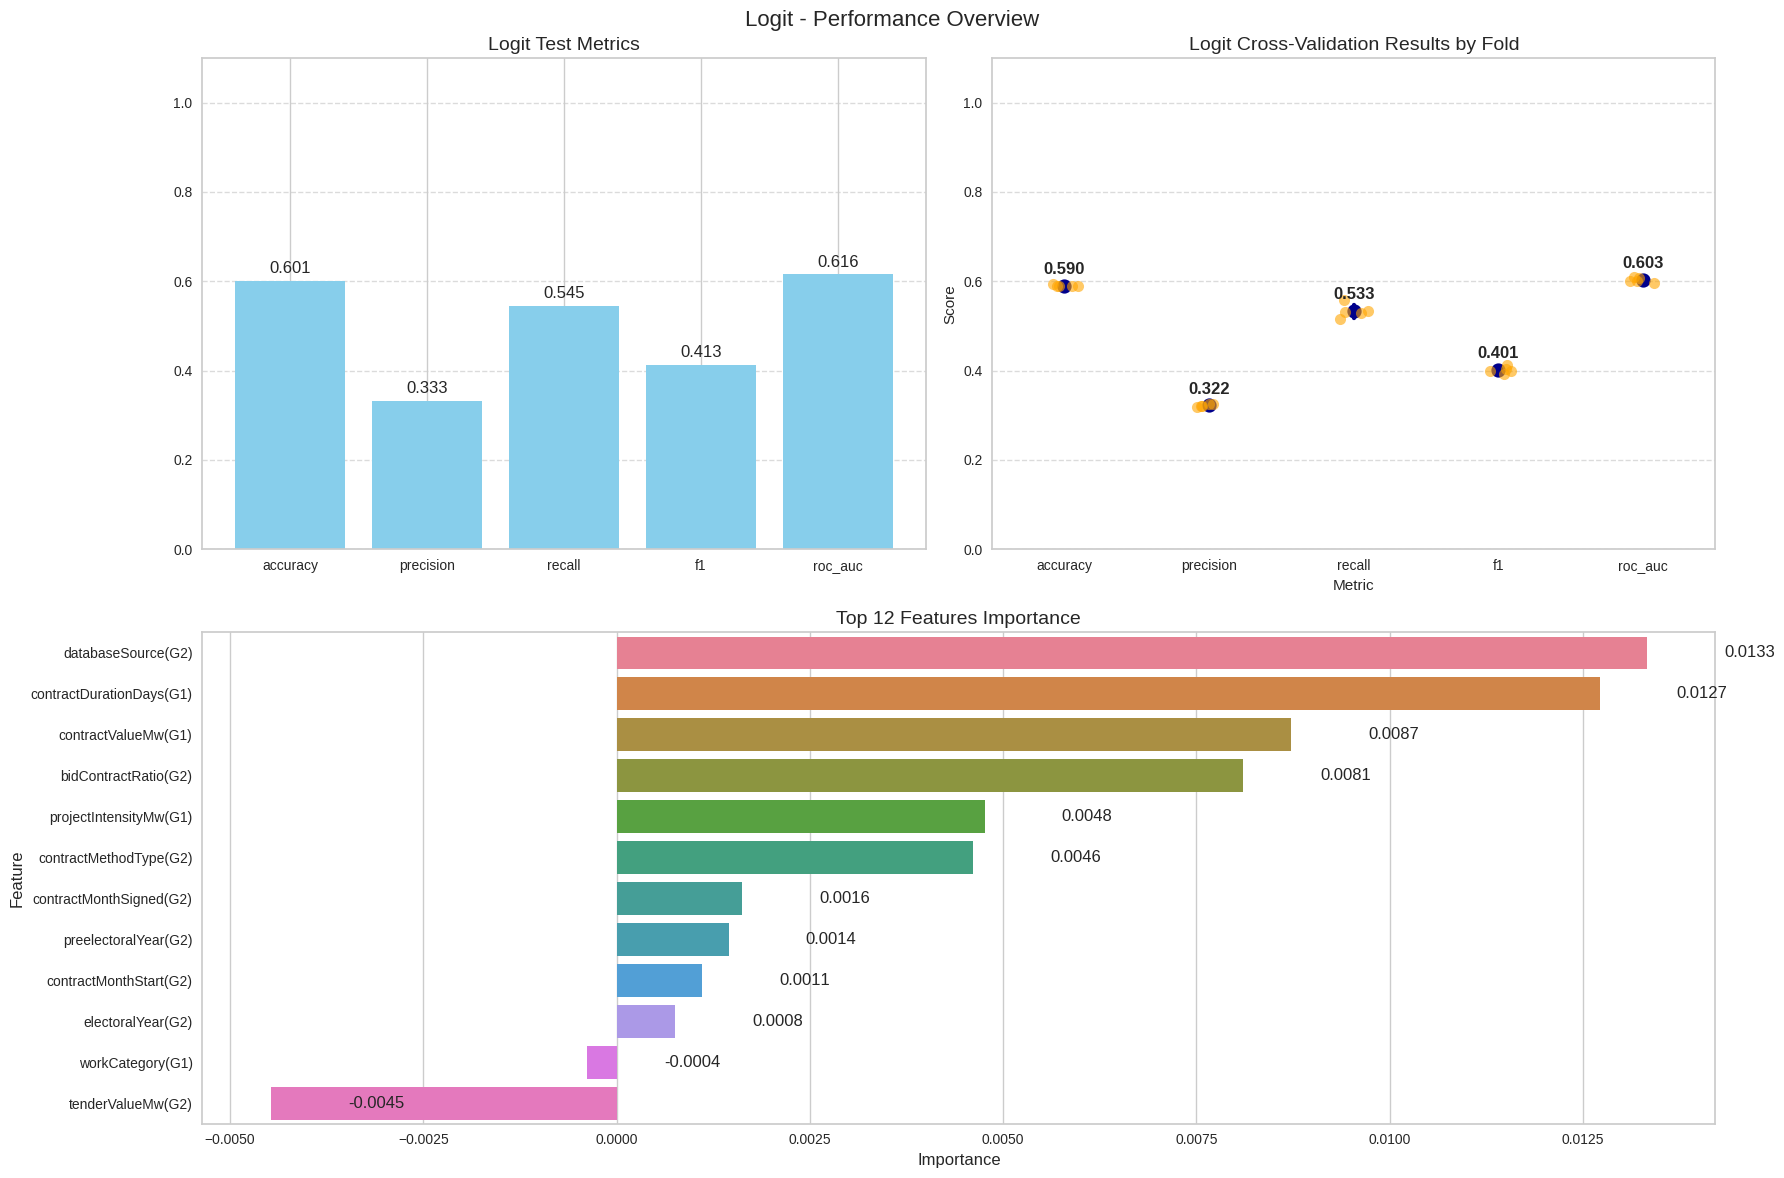

In [26]:
lr_model_s1 = LogisticRegression(random_state=42, max_iter=1000)
lr_results_s1 = train_evaluate_model(
    classifier=lr_model_s1,
    X_train=X_train_s1,
    y_train=y_train_s1,
    X_test=X_test_s1,
    y_test=y_test_s1,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="Logit",
    stage='S1',
    use_smote=True,
    perform_cv=True,
    cv=5,
    plot_results=True,
    n_top_features=15
)

### Ridge Model

Modelo Ridge entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== Ridge Performance Report =====

Test Set Metrics:
accuracy: 0.5999
precision: 0.3311
recall: 0.5412
f1: 0.4108

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.591051      0.000947         0.32271       0.003104     0.533758   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0     0.01536  0.402196  0.006703      0.602919     0.005016  


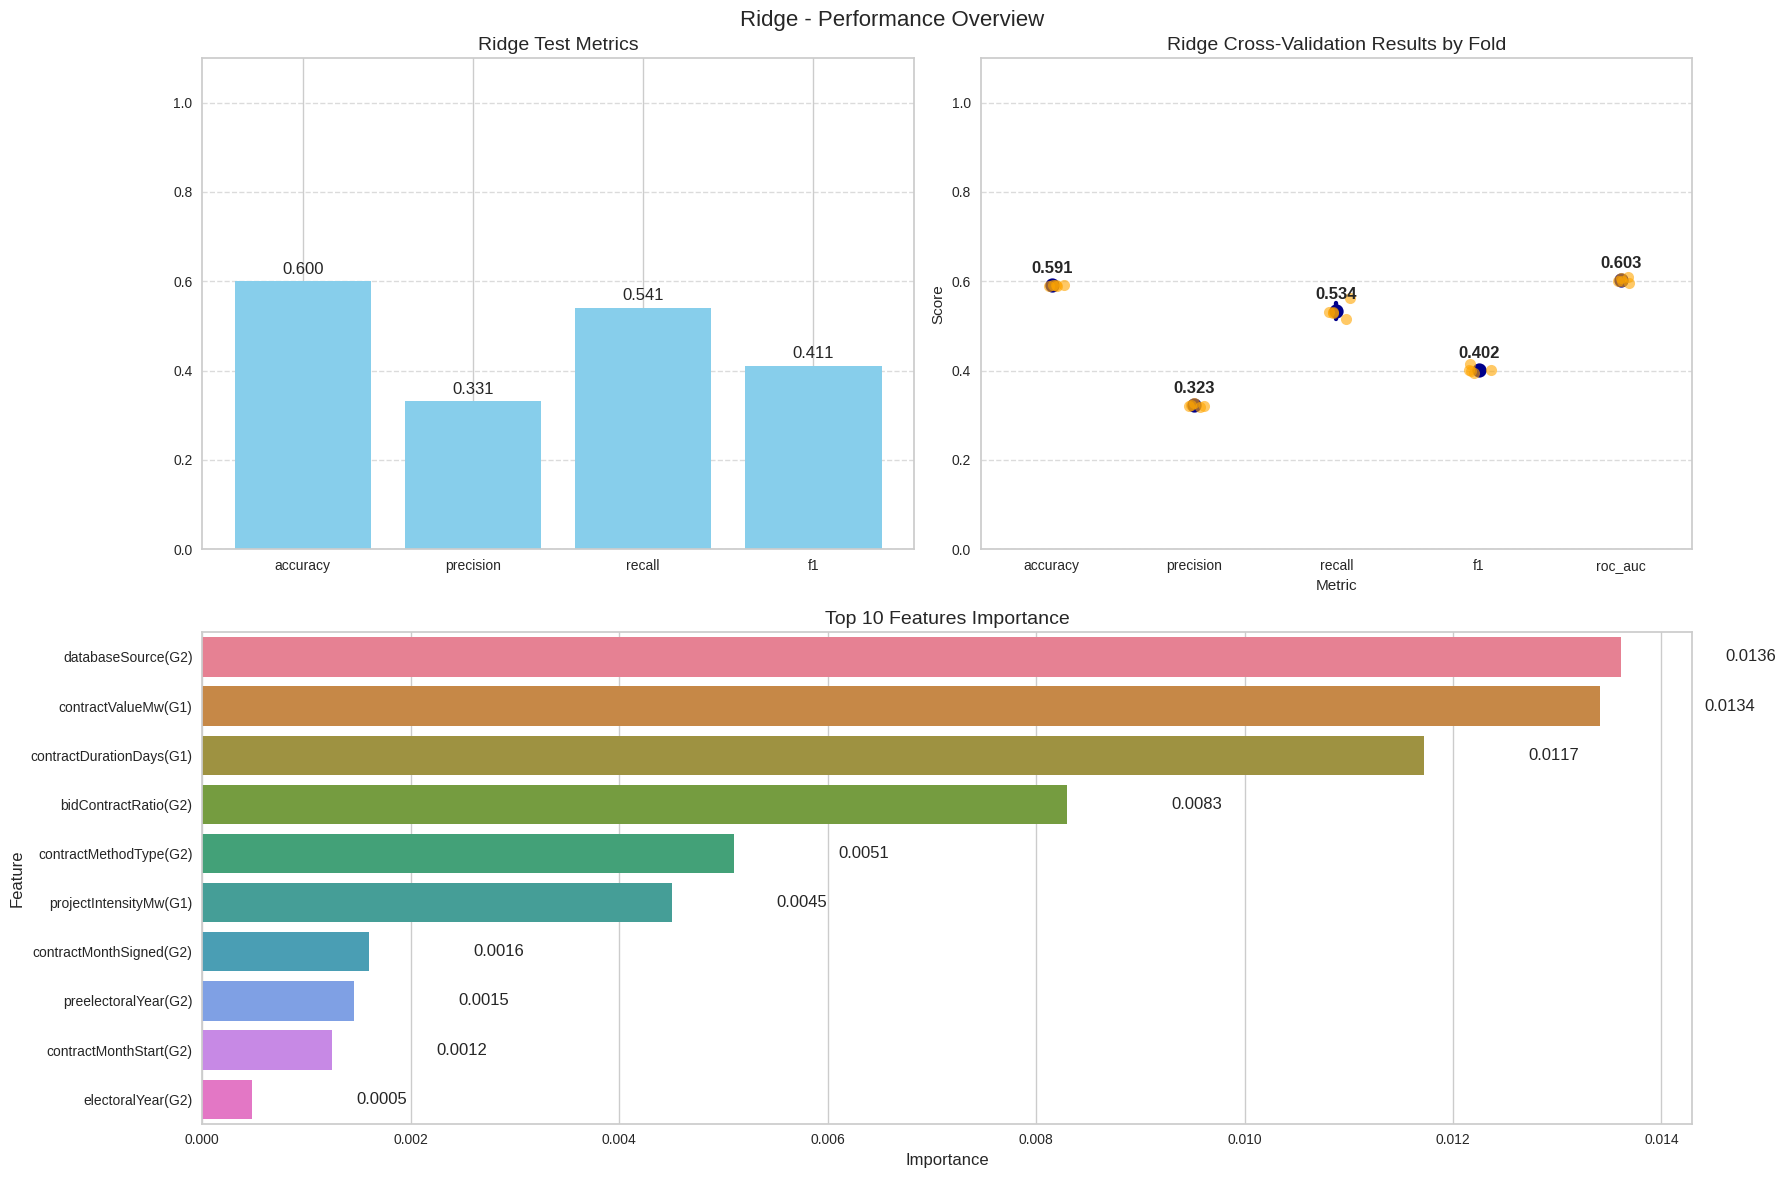

In [27]:
# Train and evaluate ridge model
ridge_model_s1 = RidgeClassifier(random_state=42)
ridge_results_s1 = train_evaluate_model(
    classifier=ridge_model_s1,
    X_train=X_train_s1,
    y_train=y_train_s1,
    X_test=X_test_s1,
    y_test=y_test_s1,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="Ridge",
    stage='S1',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### Random Forest

Modelo Random Forest entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== Random Forest Performance Report =====

Test Set Metrics:
accuracy: 0.6887
precision: 0.3629
recall: 0.2748
f1: 0.3128
roc_auc: 0.6034

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.675216      0.005162        0.334127        0.00941     0.261317   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.009081  0.293189  0.008061      0.582224      0.01073  


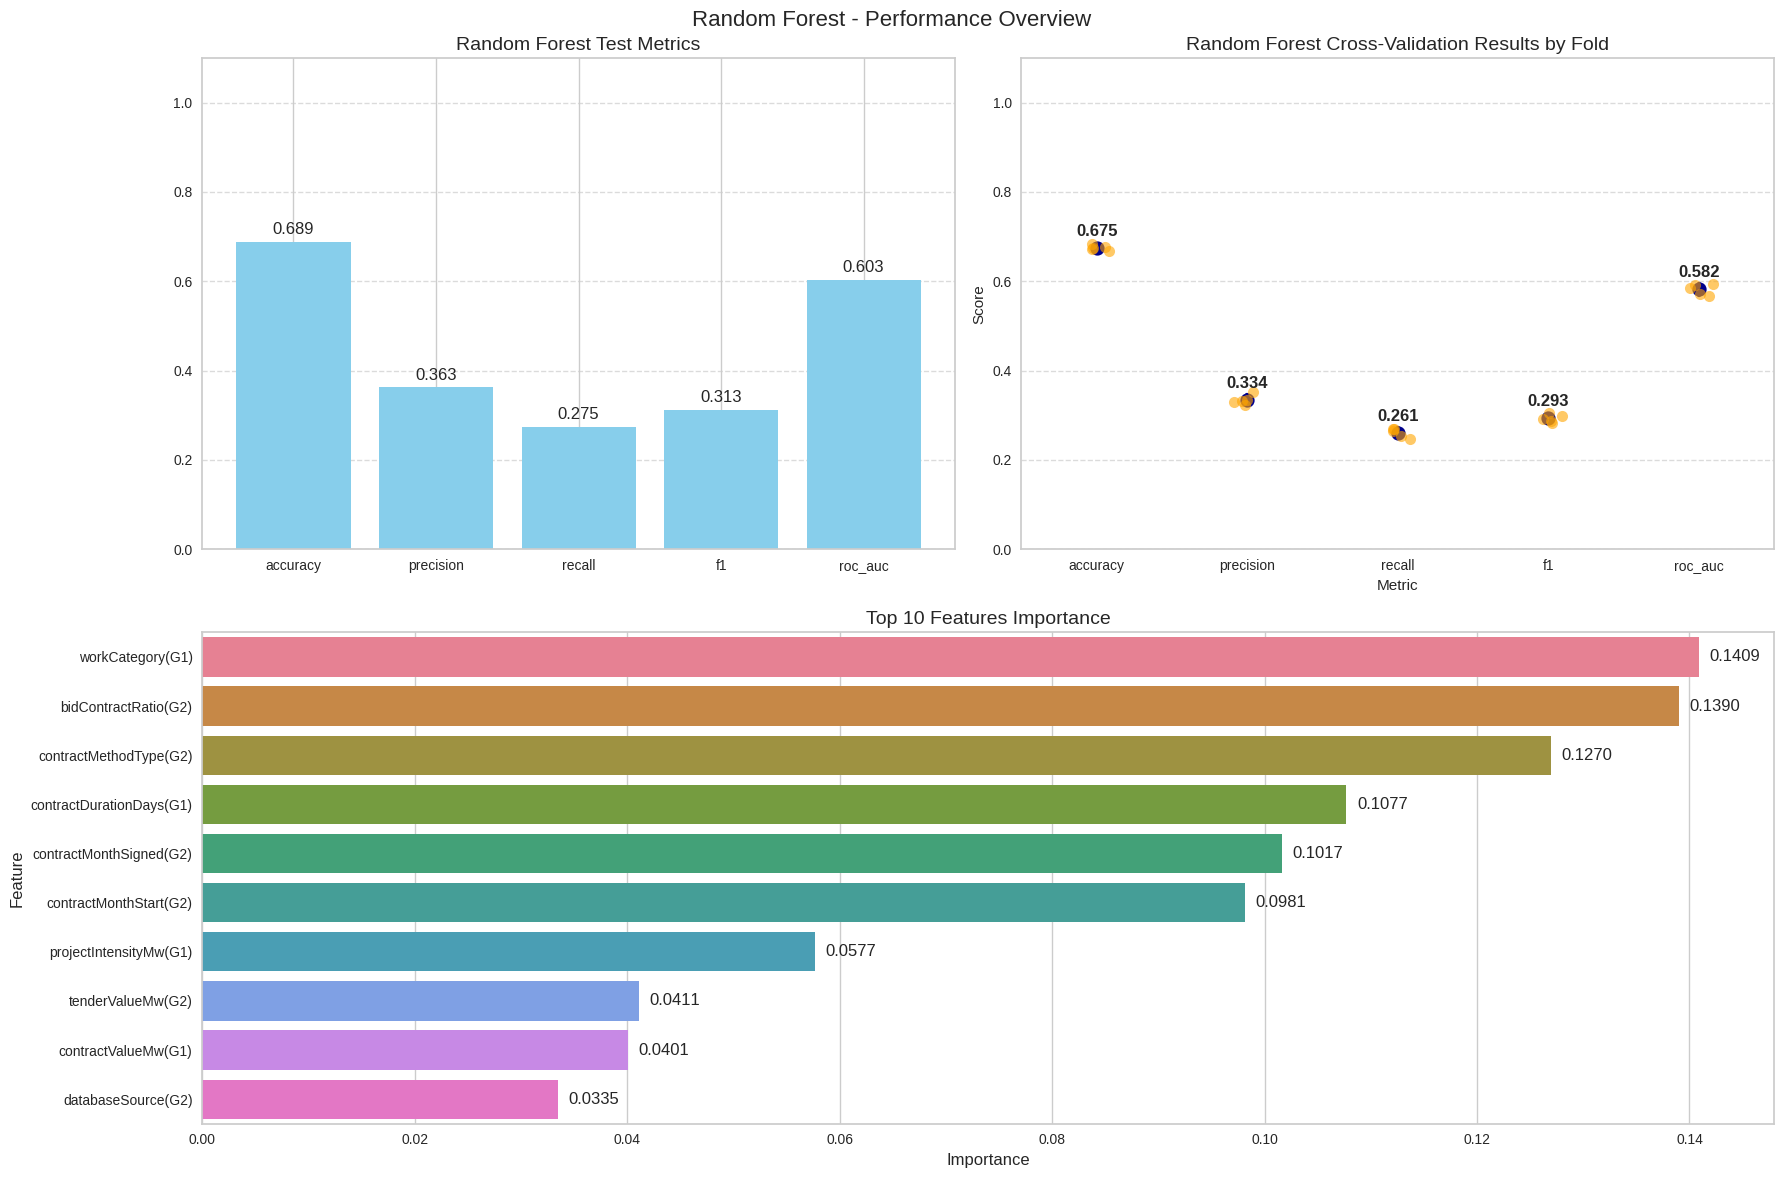

In [28]:
rf_model_s1 = RandomForestClassifier(random_state=42)
rf_results_s1 = train_evaluate_model(
    classifier=rf_model_s1,
    X_train=X_train_s1,
    y_train=y_train_s1,
    X_test=X_test_s1,
    y_test=y_test_s1,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="Random Forest",
    stage='S1',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### Extreme Gradient Boosting

Modelo XGBoost entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== XGBoost Performance Report =====

Test Set Metrics:
accuracy: 0.7016
precision: 0.3791
recall: 0.2470
f1: 0.2991
roc_auc: 0.6006

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.691292      0.002456        0.353219       0.007249     0.237692   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.010607  0.284088  0.009437      0.584202     0.005364  


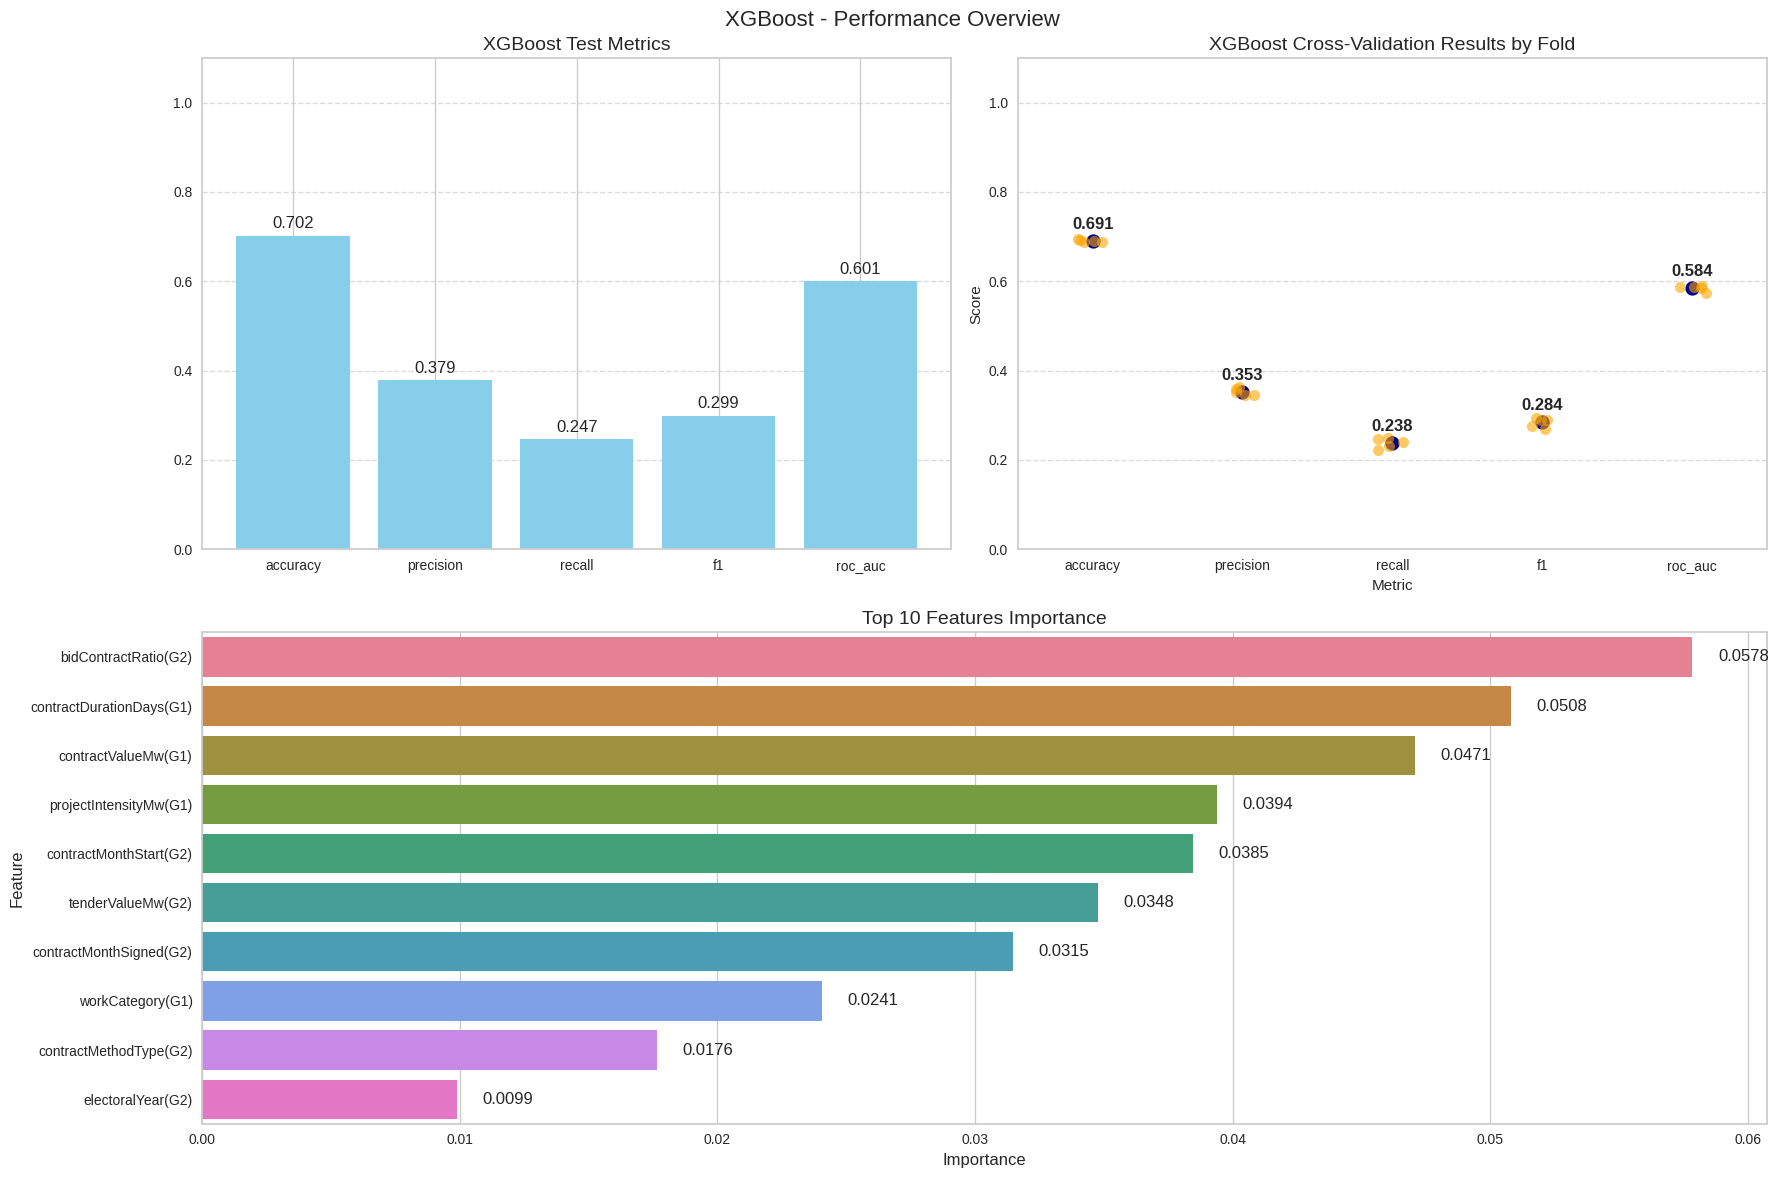

In [29]:
# Train and evaluate xgbModel
xgb_model_s1 = XGBClassifier(random_state=42)
xgb_results_s1 = train_evaluate_model(
    classifier=xgb_model_s1,
    X_train=X_train_s1,
    y_train=y_train_s1,
    X_test=X_test_s1,
    y_test=y_test_s1,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="XGBoost",
    stage='S1',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### Light Gradient Boosting

[LightGBM] [Info] Number of positive: 14497, number of negative: 14497
[LightGBM] [Info] Total Bins 7308
[LightGBM] [Info] Number of data points in the train set: 28994, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Modelo LightGBM entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}
[LightGBM] [Info] Number of positive: 11597, number of negative: 11597
[LightGBM] [Info] Total Bins 6130
[LightGBM] [Info] Number of data points in the train set: 23194, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 11597, number of negative: 11597
[LightGBM] [Info] Total Bins 6083
[LightGBM] [Info] Number of data points in the train set: 23194, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info

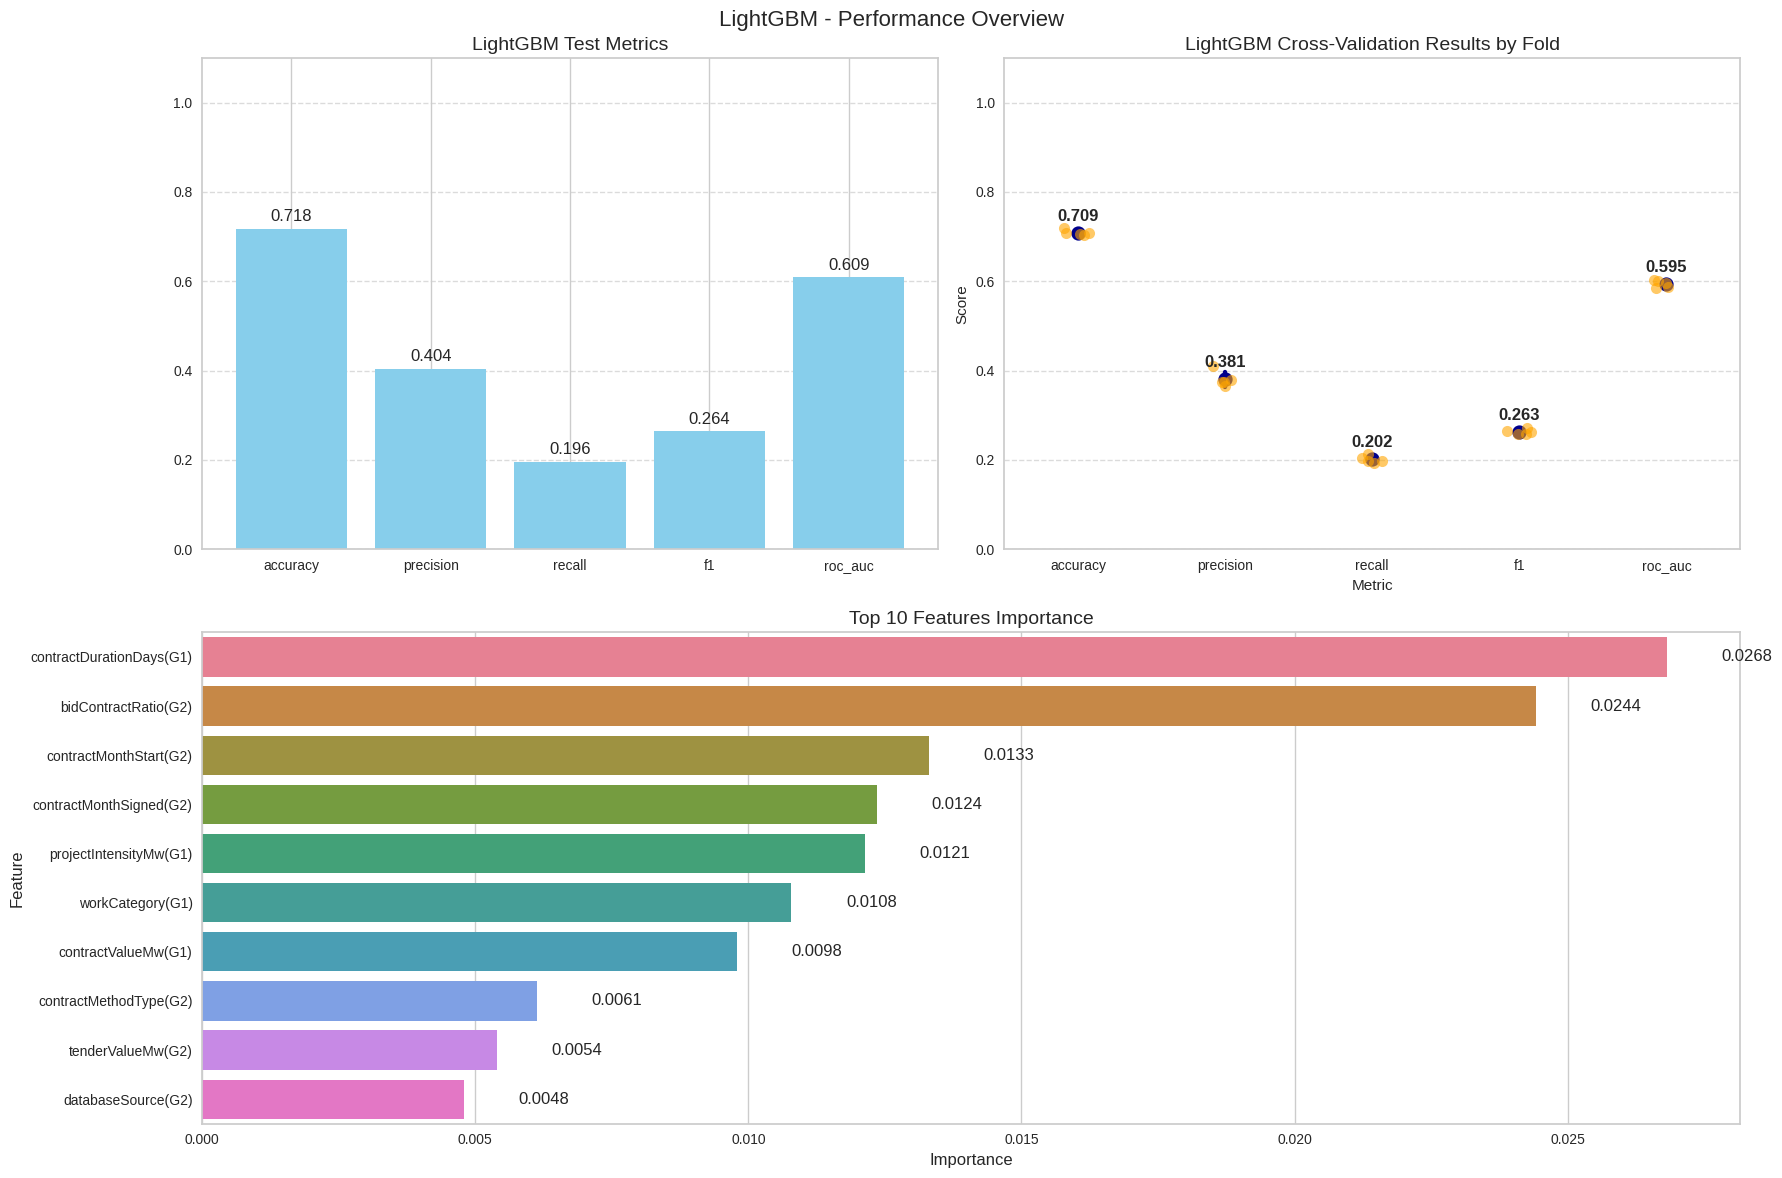

In [30]:
# Train and evaluate light gradient boosting
lgb_model_s1 = LGBMClassifier(random_state=42, force_row_wise=True)
lgb_results_s1 = train_evaluate_model(
    classifier=lgb_model_s1,
    X_train=X_train_s1,
    y_train=y_train_s1,
    X_test=X_test_s1,
    y_test=y_test_s1,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="LightGBM",
    stage='S1',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### K Nearest Neighbors

In [31]:
# Train and Evaluate KNN
knn_model_s1 = KNeighborsClassifier()
knn_results_s1 = train_evaluate_model(
    classifier=knn_model_s1,
    X_train=X_train_s1,
    y_train=y_train_s1,
    X_test=X_test_s1,
    y_test=y_test_s1,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="KNN",
    stage='S1',
    use_smote=True,
    perform_cv=True,
    plot_results=False
)

Modelo KNN entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== KNN Performance Report =====

Test Set Metrics:
accuracy: 0.5852
precision: 0.3109
recall: 0.5009
f1: 0.3837
roc_auc: 0.5755

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.567502      0.008321        0.291447        0.00649     0.473388   

   recall_std   f1_mean   f1_std  roc_auc_mean  roc_auc_std  
0    0.019797  0.360667  0.00936      0.549469     0.009161  


### Suport Vector Machine

In [32]:
# Train and evaluate SVC model
svc_model_s1 = SVC(random_state=42)
svc_results_s1 = train_evaluate_model(
    classifier=svc_model_s1,
    X_train=X_train_s1,
    y_train=y_train_s1,
    X_test=X_test_s1,
    y_test=y_test_s1,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="SVC",
    stage='S1',
    use_smote=True,
    perform_cv=True,
    plot_results=False
)

Modelo SVC entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== SVC Performance Report =====

Test Set Metrics:
accuracy: 0.6220
precision: 0.3360
recall: 0.4782
f1: 0.3947

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.614089       0.00764         0.32879        0.00996     0.477161   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.018722  0.389276  0.012685      0.602202     0.009294  


### Neural Network

In [33]:
# Train Neural Network
nn_model_s1 = MLPClassifier(random_state=42, max_iter=1000)
nn_results_s1 = train_evaluate_model(
    classifier=nn_model_s1,
    X_train=X_train_s1,
    y_train=y_train_s1,
    X_test=X_test_s1,
    y_test=y_test_s1,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="Neural Network",
    stage='S1',
    use_smote=True,
    perform_cv=True,
    plot_results=False
)


Modelo Neural Network entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== Neural Network Performance Report =====

Test Set Metrics:
accuracy: 0.6217
precision: 0.3158
recall: 0.4008
f1: 0.3533
roc_auc: 0.5608

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.622383      0.015773        0.308849       0.008461     0.373309   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.028787  0.337215  0.010121      0.555767     0.006306  


### Consolidate results

In [34]:
# Consolidate scores of all models
lr_results_s1['metrics'].update({'Model': 'Logit'})
lr_results_s1['metrics'].update({'Stage': 'S1'})
lr_results_s1_df = pd.DataFrame(lr_results_s1['metrics'], index=[0])

ridge_results_s1['metrics'].update({'Model': 'Ridge'})
ridge_results_s1['metrics'].update({'Stage': 'S1'})
ridge_results_s1_df = pd.DataFrame(ridge_results_s1['metrics'], index=[0])

rf_results_s1['metrics'].update({'Model': 'Random Forest'})
rf_results_s1['metrics'].update({'Stage': 'S1'})
rf_results_s1_df = pd.DataFrame(rf_results_s1['metrics'], index=[0])

xgb_results_s1['metrics'].update({'Model': 'XGBoost'})
xgb_results_s1['metrics'].update({'Stage': 'S1'})
xgb_results_s1_df = pd.DataFrame(xgb_results_s1['metrics'], index=[0])

lgb_results_s1['metrics'].update({'Model': 'LightGBM'})
lgb_results_s1['metrics'].update({'Stage': 'S1'})
lgb_results_s1_df = pd.DataFrame(lgb_results_s1['metrics'], index=[0])

knn_results_s1['metrics'].update({'Model': 'KNN'})
knn_results_s1['metrics'].update({'Stage': 'S1'})
knn_results_s1_df = pd.DataFrame(knn_results_s1['metrics'], index=[0])

svc_results_s1['metrics'].update({'Model': 'SVC'})
svc_results_s1['metrics'].update({'Stage': 'S1'})
svc_results_s1_df = pd.DataFrame(svc_results_s1['metrics'], index=[0])

nn_results_s1['metrics'].update({'Model': 'Neural Network'})
nn_results_s1['metrics'].update({'Stage': 'S1'})
nn_results_s1_df = pd.DataFrame(nn_results_s1['metrics'], index=[0])

# consolidate all data frame
scores_df_s1 = pd.concat([lr_results_s1_df,
                       ridge_results_s1_df,
                       rf_results_s1_df,
                       xgb_results_s1_df,
                       lgb_results_s1_df,
                       knn_results_s1_df,
                       svc_results_s1_df,
                       nn_results_s1_df],
                      ignore_index=True)

# Calcular la media para las columnas numéricas
mean_values = scores_df_s1.select_dtypes(include=['number']).mean()
mean_row = pd.Series({'Stage': 'S1', 'Model': 'Mean'})
for col in mean_values.index:
    mean_row[col] = mean_values[col]

# Calcular la desviación estándar para las columnas numéricas
std_values = scores_df_s1.select_dtypes(include=['number']).std()
std_row = pd.Series({'Stage': 'S1', 'Model': 'Std'})
for col in std_values.index:
    std_row[col] = std_values[col]

# Añadir las filas al DataFrame
scores_df_s1 = pd.concat([scores_df_s1, pd.DataFrame([mean_row, std_row])], ignore_index=True)
print((scores_df_s1))

   accuracy  precision    recall        f1   roc_auc           Model Stage
0  0.601171   0.332956  0.545412  0.413490  0.616364           Logit    S1
1  0.599857   0.331066  0.541242  0.410834       NaN           Ridge    S1
2  0.688724   0.362913  0.274791  0.312764  0.603402   Random Forest    S1
3  0.701624   0.379090  0.246988  0.299102  0.600591         XGBoost    S1
4  0.718227   0.404011  0.196015  0.263963  0.608977        LightGBM    S1
5  0.585165   0.310900  0.500927  0.383673  0.575525             KNN    S1
6  0.621954   0.336047  0.478221  0.394722       NaN             SVC    S1
7  0.621715   0.315809  0.400834  0.353278  0.560759  Neural Network    S1
8  0.642305   0.346599  0.398054  0.353978  0.594269            Mean    S1
9  0.052146   0.032468  0.140443  0.056226  0.021457             Std    S1


## Stage 2: Project, contract and buyer and supplier characteristics

In [35]:
# Separate features and target
X2 = df[projectsColumns + contractColumns + buyerColumns + supplierColumns]
y2 = df['haveCostDeviation(G7)']

In [36]:
# select categorical columns
categoricalColumns = X2.select_dtypes(include=['object']).columns
# select numerical columns
numericColumns = X2.select_dtypes(include=['int64', 'float64']).columns

In [37]:
# Split data into training and testing sets
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(X2, y2, test_size=0.3, random_state=42, stratify=y2)

### Logistic Regression

Modelo Logistic Regression entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== Logistic Regression Performance Report =====

Test Set Metrics:
accuracy: 0.6154
precision: 0.3636
recall: 0.6557
f1: 0.4678
roc_auc: 0.6803

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.604208      0.008651        0.352036       0.007969     0.636223   

   recall_std   f1_mean   f1_std  roc_auc_mean  roc_auc_std  
0    0.010632  0.453256  0.00908      0.663384      0.00927  


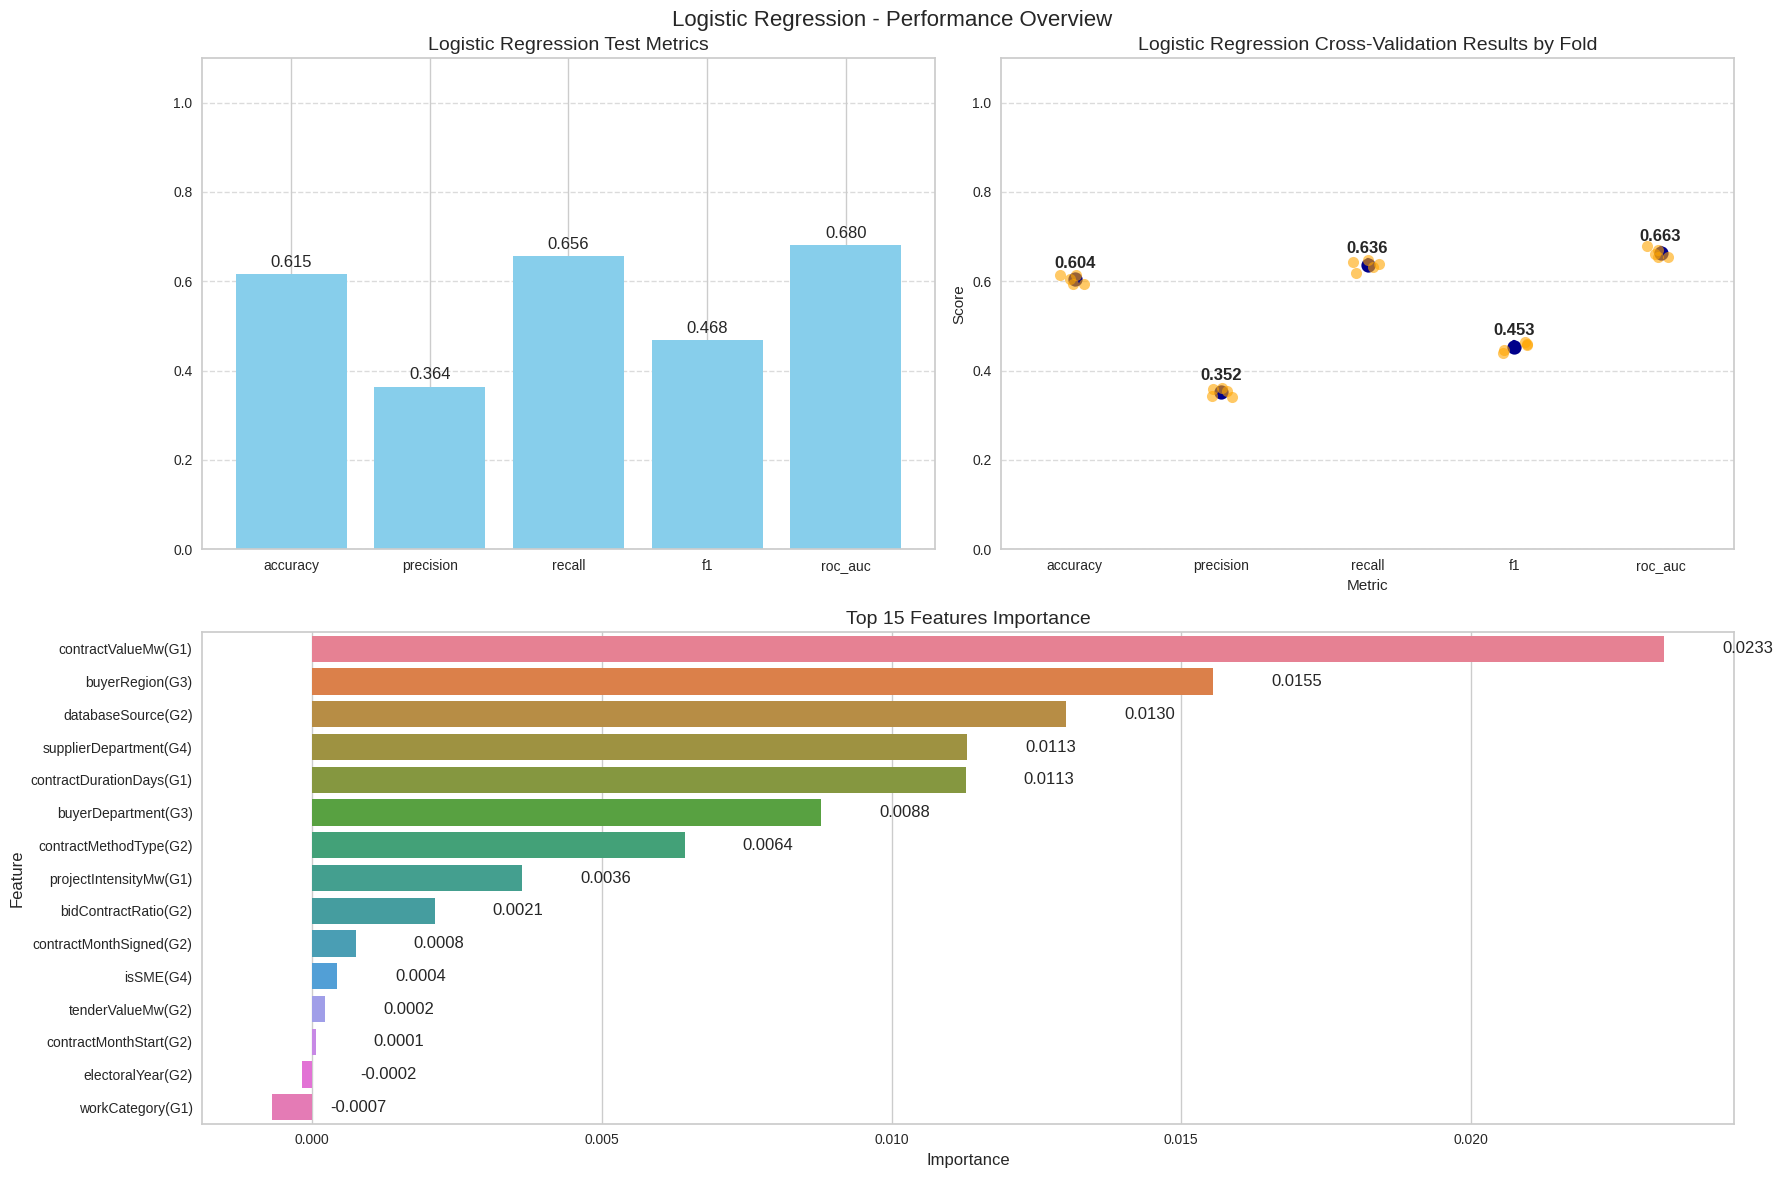

In [38]:
lr_model_s2 = LogisticRegression(random_state=42, max_iter=1000)
lr_results_s2 = train_evaluate_model(
    classifier=lr_model_s2,
    X_train=X_train_s2,
    y_train=y_train_s2,
    X_test=X_test_s2,
    y_test=y_test_s2,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="Logistic Regression",
    stage='S2',
    use_smote=True,
    perform_cv=True,
    cv=5,
    plot_results=True,
    n_top_features=15
)

### Ridge Model

Modelo Ridge entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== Ridge Performance Report =====

Test Set Metrics:
accuracy: 0.6113
precision: 0.3606
recall: 0.6566
f1: 0.4655

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.602826      0.009532        0.351548       0.009018     0.639599   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.012584  0.453708  0.010567      0.663131     0.009316  


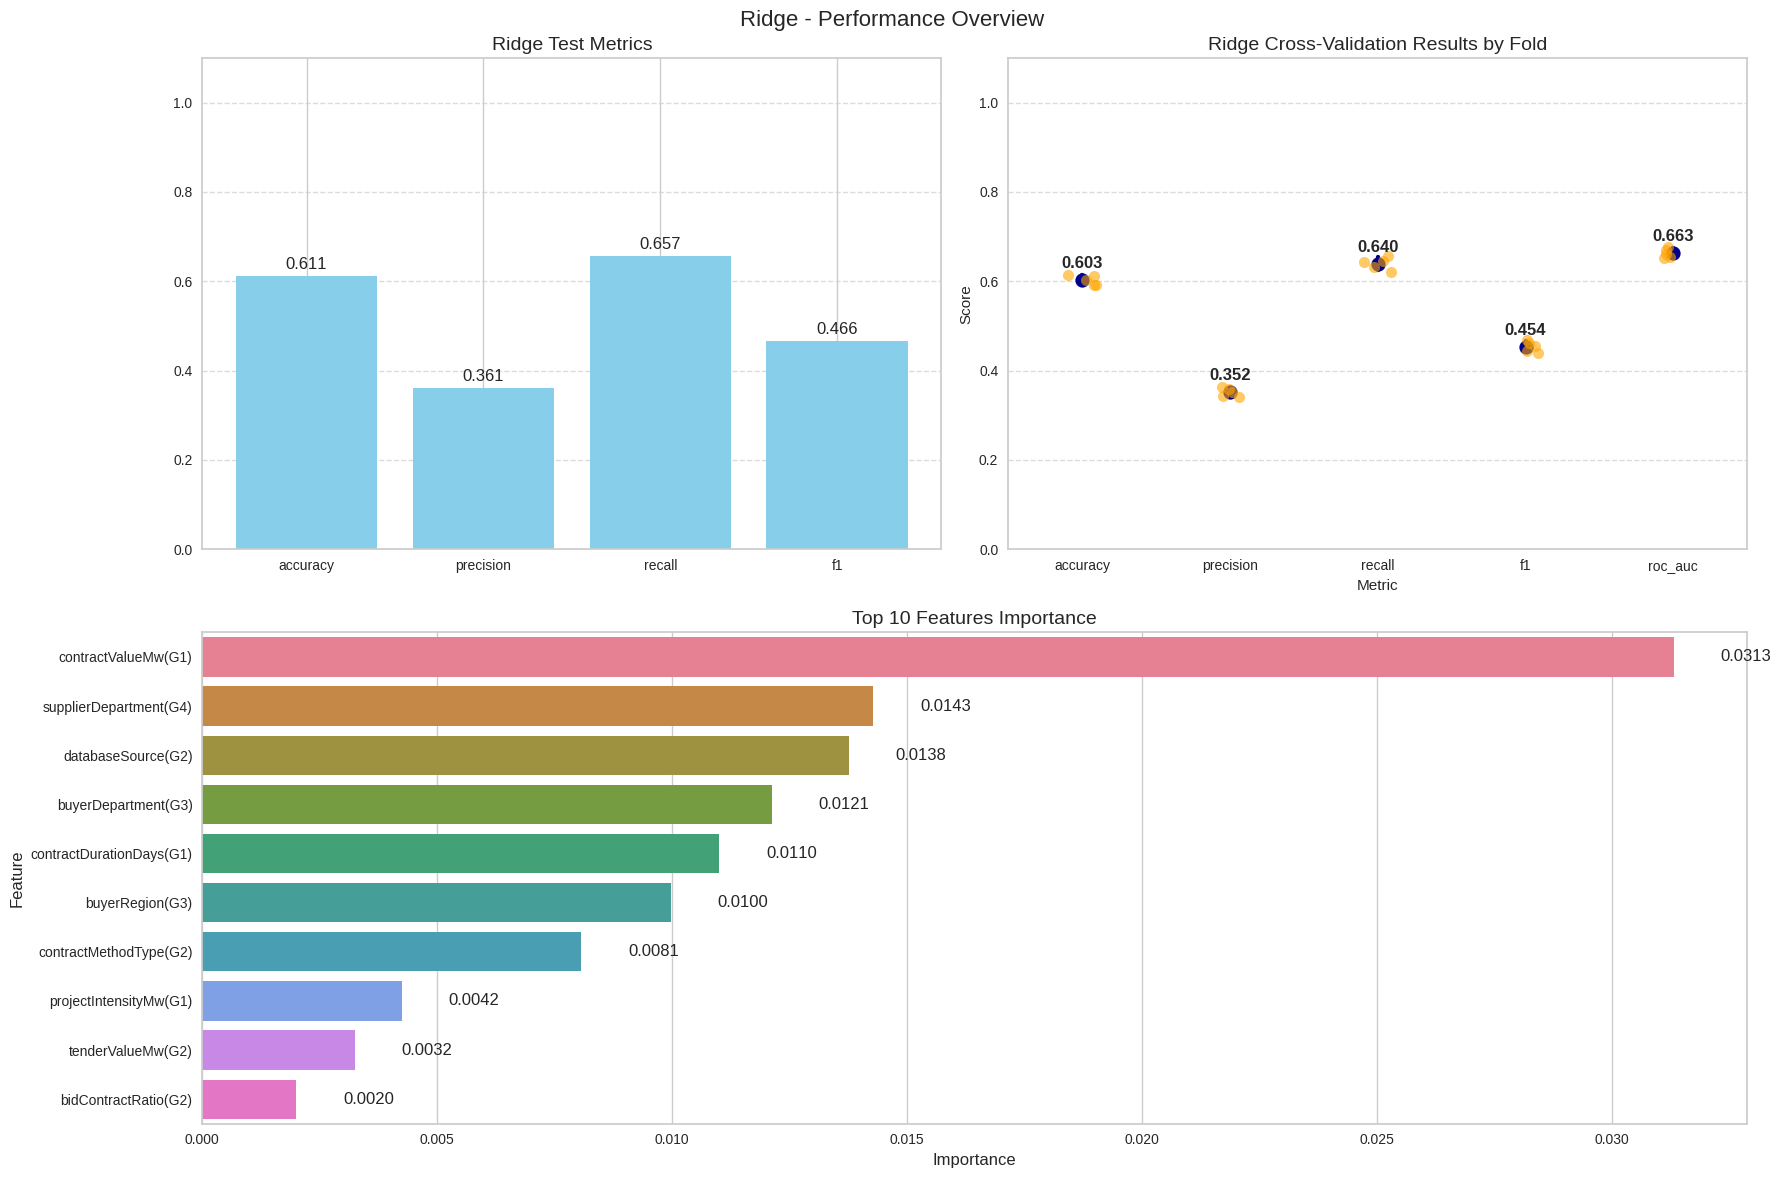

In [39]:
# Train and evaluate ridge model
ridge_model_s2 = RidgeClassifier(random_state=42)
ridge_results_s2 = train_evaluate_model(
    classifier=ridge_model_s2,
    X_train=X_train_s2,
    y_train=y_train_s2,
    X_test=X_test_s2,
    y_test=y_test_s2,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="Ridge",
    stage='S2',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### Random Forest

Modelo Random Forest entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== Random Forest Performance Report =====

Test Set Metrics:
accuracy: 0.7316
precision: 0.4654
recall: 0.2771
f1: 0.3474
roc_auc: 0.6828

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.726463      0.004775        0.445355       0.015102     0.247022   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.008076  0.317704  0.009319      0.664722     0.008503  


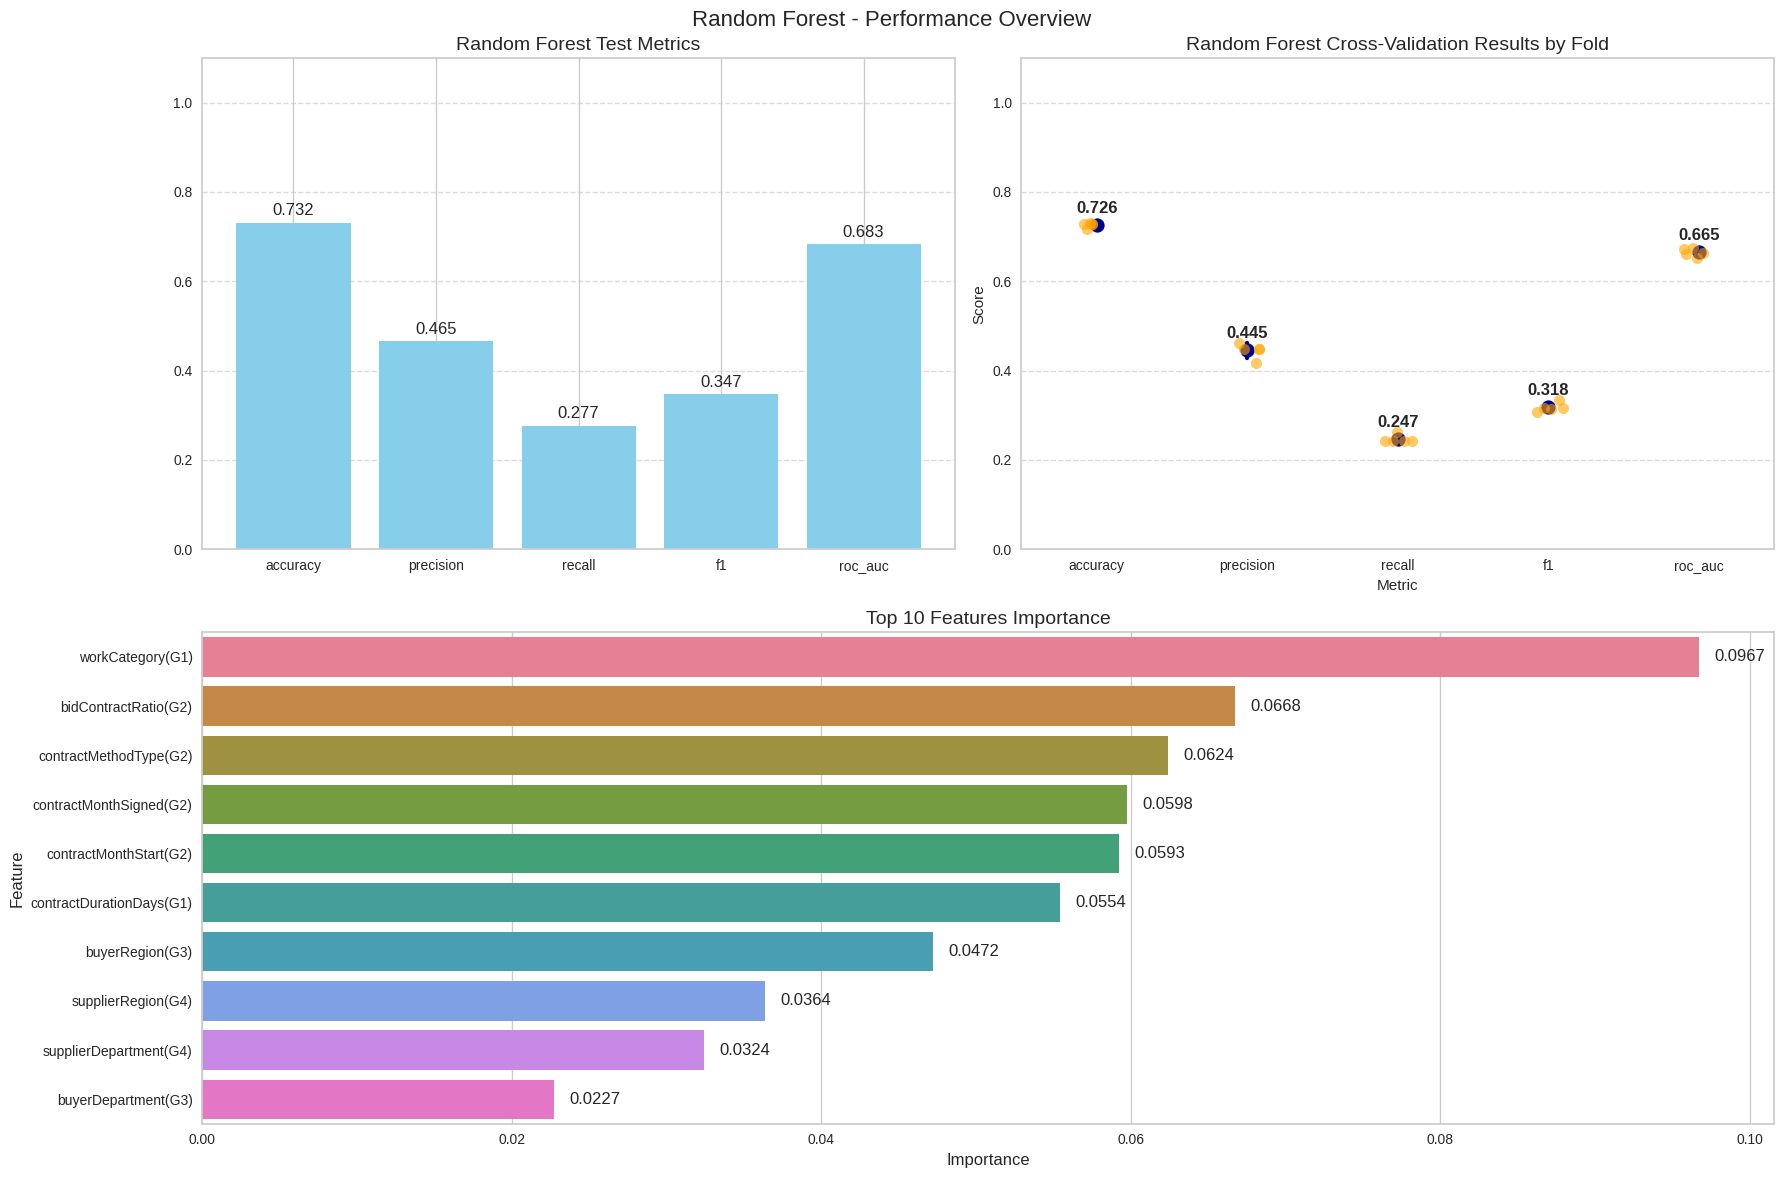

In [40]:
rf_model_s2 = RandomForestClassifier(random_state=42)
rf_results_s2 = train_evaluate_model(
    classifier=rf_model_s2,
    X_train=X_train_s2,
    y_train=y_train_s2,
    X_test=X_test_s2,
    y_test=y_test_s2,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="Random Forest",
    stage='S2',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### Extreme Gradient Boosting

Modelo XGBoost entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== XGBoost Performance Report =====

Test Set Metrics:
accuracy: 0.7395
precision: 0.4884
recall: 0.2243
f1: 0.3074
roc_auc: 0.6723

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.732402      0.003283        0.459373       0.014241      0.21704   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.016676  0.294611  0.017837      0.663634     0.005433  


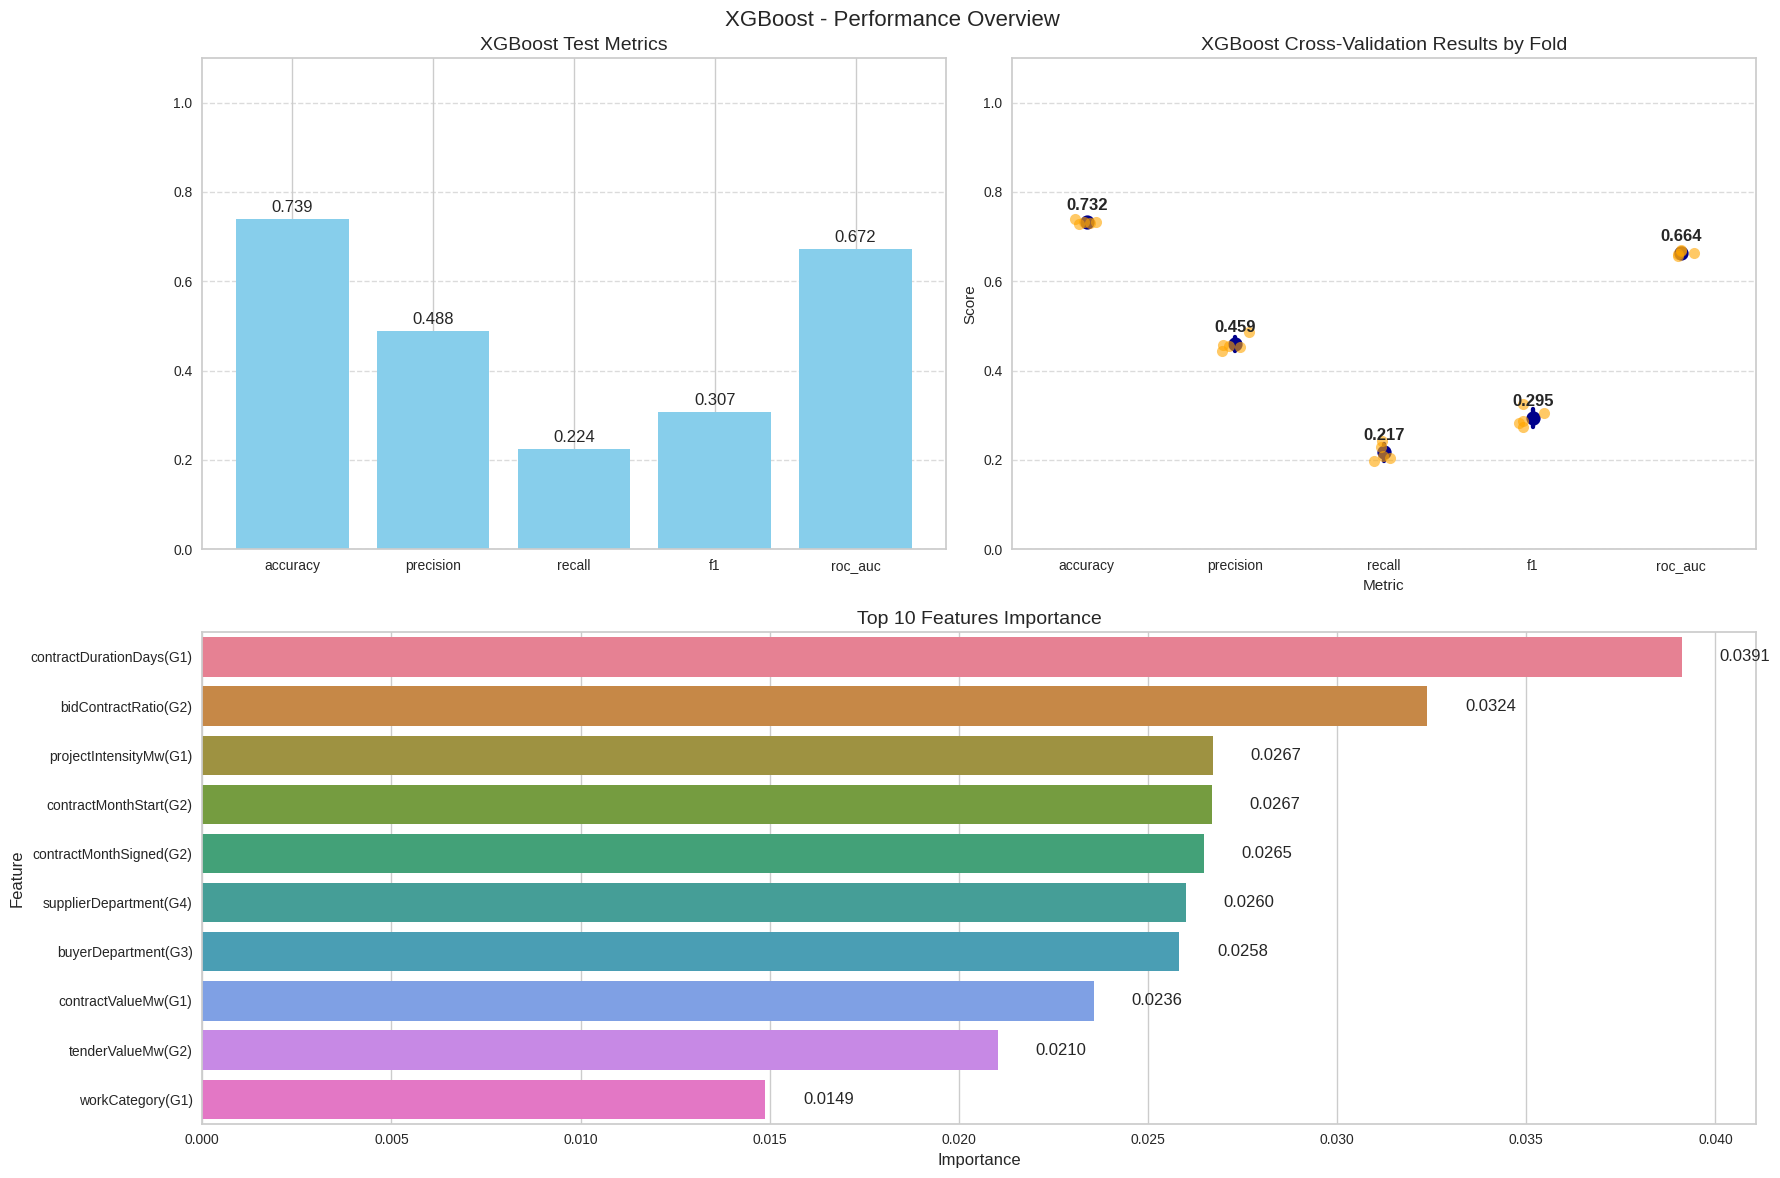

In [41]:
# Train and evaluate xgbModel
xgb_model_s2 = XGBClassifier(random_state=42)
xgb_results_s2 = train_evaluate_model(
    classifier=xgb_model_s2,
    X_train=X_train_s2,
    y_train=y_train_s2,
    X_test=X_test_s2,
    y_test=y_test_s2,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="XGBoost",
    stage='S2',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### Light Gradient Boosting

[LightGBM] [Info] Number of positive: 14497, number of negative: 14497
[LightGBM] [Info] Total Bins 16159
[LightGBM] [Info] Number of data points in the train set: 28994, number of used features: 127
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Modelo LightGBM entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}
[LightGBM] [Info] Number of positive: 11597, number of negative: 11597
[LightGBM] [Info] Total Bins 15534
[LightGBM] [Info] Number of data points in the train set: 23194, number of used features: 126
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 11597, number of negative: 11597
[LightGBM] [Info] Total Bins 15449
[LightGBM] [Info] Number of data points in the train set: 23194, number of used features: 126
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM]

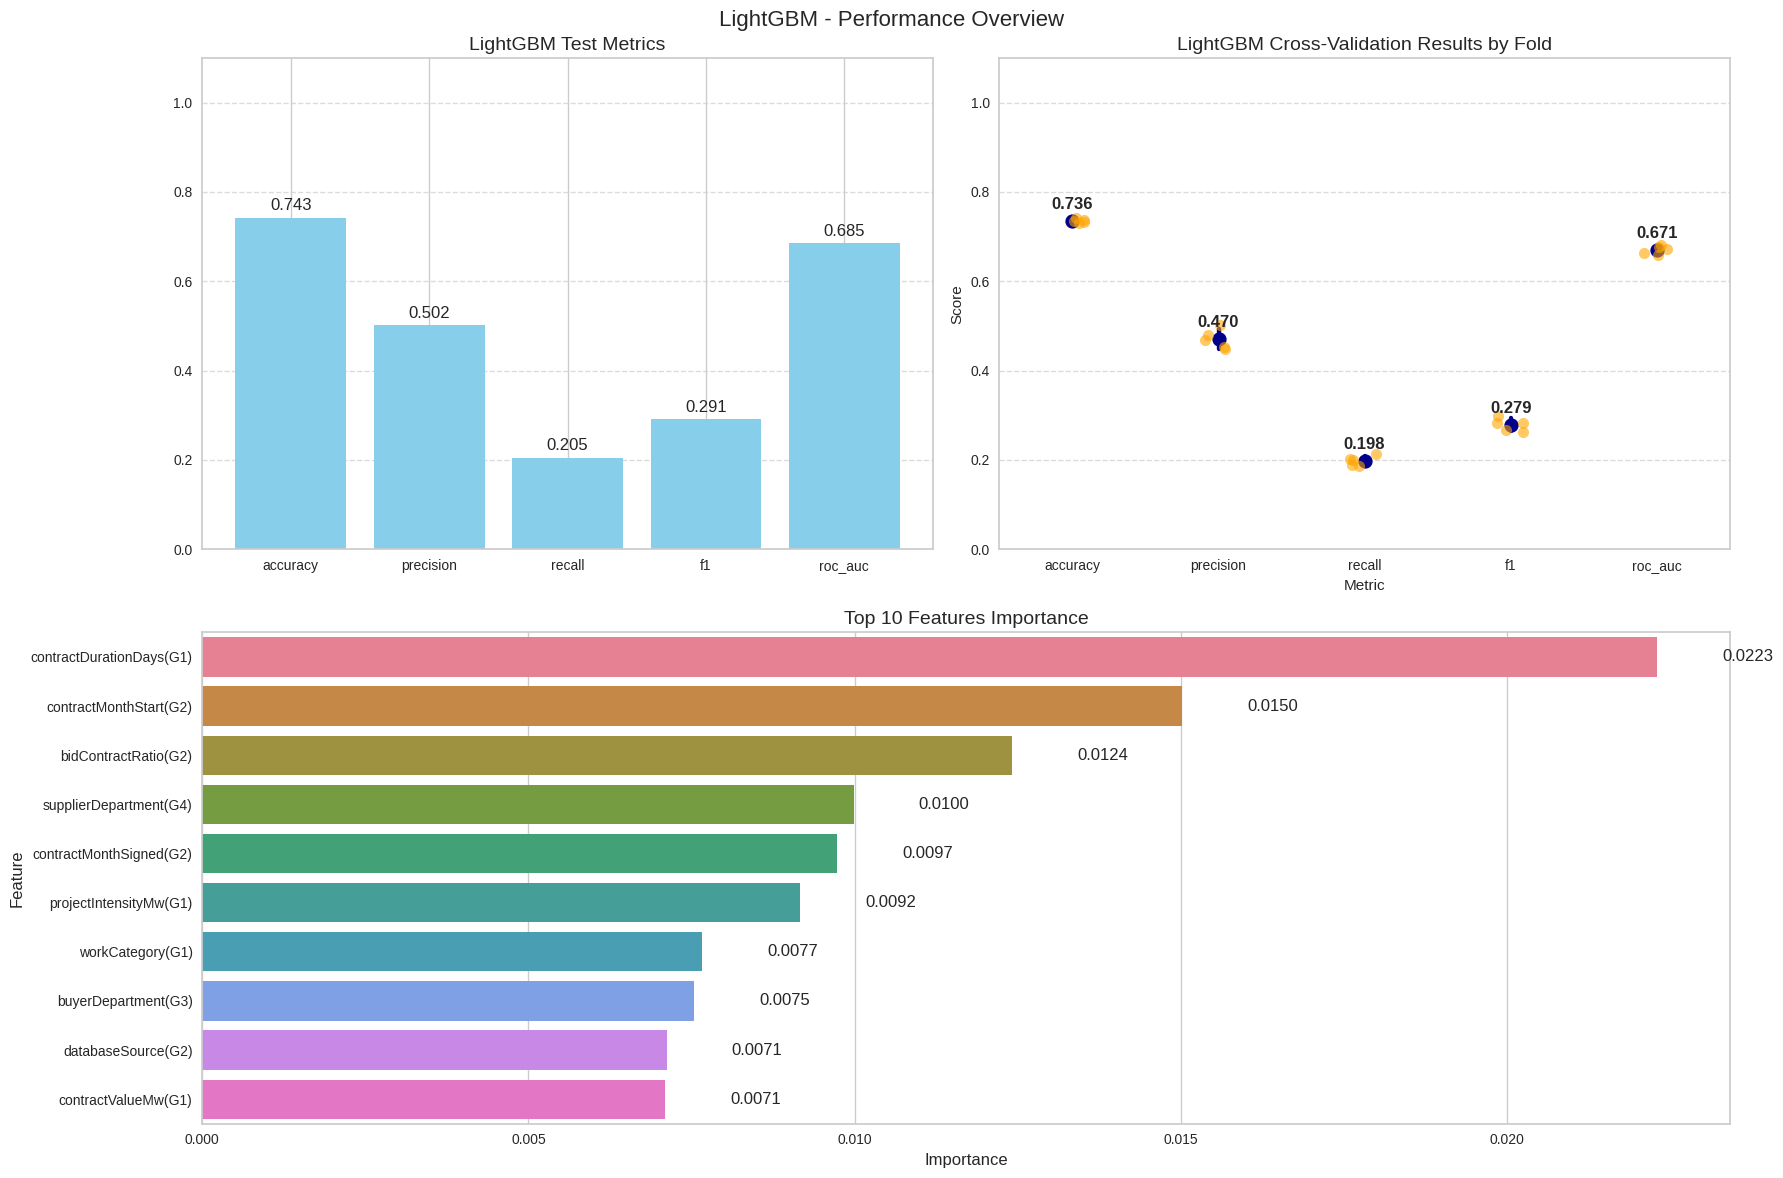

In [42]:
# Train and evaluate light gradient boosting
lgb_model_s2 = LGBMClassifier(random_state=42, force_row_wise=True)
lgb_results_s2 = train_evaluate_model(
    classifier=lgb_model_s2,
    X_train=X_train_s2,
    y_train=y_train_s2,
    X_test=X_test_s2,
    y_test=y_test_s2,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="LightGBM",
    stage='S2',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### K Nearest Neighbors

In [43]:
# Train and Evaluate KNN
knn_model_s2 = KNeighborsClassifier()
knn_results_s2 = train_evaluate_model(
    classifier=knn_model_s2,
    X_train=X_train_s2,
    y_train=y_train_s2,
    X_test=X_test_s2,
    y_test=y_test_s2,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="KNN",
    stage='S2',
    use_smote=True,
    perform_cv=True,
    plot_results=False
)

Modelo KNN entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== KNN Performance Report =====

Test Set Metrics:
accuracy: 0.5671
precision: 0.3189
recall: 0.5982
f1: 0.4160
roc_auc: 0.6035

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.561717       0.01092        0.317083       0.006717     0.606032   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.014905  0.416247  0.007051      0.603344     0.008807  


### Suport Vector Machine

In [44]:
# Train and evaluate SVC model
svc_model_s2 = SVC(random_state=42)
svc_results_s2 = train_evaluate_model(
    classifier=svc_model_s2,
    X_train=X_train_s2,
    y_train=y_train_s2,
    X_test=X_test_s2,
    y_test=y_test_s2,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="SVC",
    stage='S2',
    use_smote=True,
    perform_cv=True,
    plot_results=False
)

Modelo SVC entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== SVC Performance Report =====

Test Set Metrics:
accuracy: 0.6562
precision: 0.3800
recall: 0.5283
f1: 0.4420

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.659756       0.00773        0.381257       0.010319      0.51291   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.014225  0.437355  0.011273      0.656559     0.008492  


### Neural Network

In [45]:
# Train Neural Network
nn_model_s2 = MLPClassifier(random_state=42, max_iter=1000)
nn_results_s2 = train_evaluate_model(
    classifier=nn_model_s2,
    X_train=X_train_s2,
    y_train=y_train_s2,
    X_test=X_test_s2,
    y_test=y_test_s2,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="Neural Network",
    stage='S2',
    use_smote=True,
    perform_cv=True,
    plot_results=False
)

Modelo Neural Network entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== Neural Network Performance Report =====

Test Set Metrics:
accuracy: 0.6585
precision: 0.3494
recall: 0.3767
f1: 0.3625
roc_auc: 0.6166

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.663902      0.012748        0.352568        0.01386     0.361008   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.030311  0.355947  0.016621      0.613994     0.011736  


### Consolidate results

In [46]:
# Consolidate scores of all models
lr_results_s2['metrics'].update({'Model': 'Logit'})
lr_results_s2['metrics'].update({'Stage': 'S2'})
lr_results_s2_df = pd.DataFrame(lr_results_s2['metrics'], index=[0])

ridge_results_s2['metrics'].update({'Model': 'Ridge'})
ridge_results_s2['metrics'].update({'Stage': 'S2'})
ridge_results_s2_df = pd.DataFrame(ridge_results_s2['metrics'], index=[0])

rf_results_s2['metrics'].update({'Model': 'Random Forest'})
rf_results_s2['metrics'].update({'Stage': 'S2'})
rf_results_s2_df = pd.DataFrame(rf_results_s2['metrics'], index=[0])

xgb_results_s2['metrics'].update({'Model': 'XGBoost'})
xgb_results_s2['metrics'].update({'Stage': 'S2'})
xgb_results_s2_df = pd.DataFrame(xgb_results_s2['metrics'], index=[0])

lgb_results_s2['metrics'].update({'Model': 'LightGBM'})
lgb_results_s2['metrics'].update({'Stage': 'S2'})
lgb_results_s2_df = pd.DataFrame(lgb_results_s2['metrics'], index=[0])

knn_results_s2['metrics'].update({'Model': 'KNN'})
knn_results_s2['metrics'].update({'Stage': 'S2'})
knn_results_s2_df = pd.DataFrame(knn_results_s2['metrics'], index=[0])

svc_results_s2['metrics'].update({'Model': 'SVC'})
svc_results_s2['metrics'].update({'Stage': 'S2'})
svc_results_s2_df = pd.DataFrame(svc_results_s2['metrics'], index=[0])

nn_results_s2['metrics'].update({'Model': 'Neural Network'})
nn_results_s2['metrics'].update({'Stage': 'S2'})
nn_results_s2_df = pd.DataFrame(nn_results_s2['metrics'], index=[0])

# consolidate all data frame
scores_df_s2 = pd.concat([lr_results_s2_df,
                       ridge_results_s2_df,
                       rf_results_s2_df,
                       xgb_results_s2_df,
                       lgb_results_s2_df,
                       knn_results_s2_df,
                       svc_results_s2_df,
                       nn_results_s2_df],
                      ignore_index=True)


# Calcular la media para las columnas numéricas
mean_values = scores_df_s2.select_dtypes(include=['number']).mean()
mean_row = pd.Series({'Stage': 'S2', 'Model': 'Mean'})
for col in mean_values.index:
    mean_row[col] = mean_values[col]

# Calcular la desviación estándar para las columnas numéricas
std_values = scores_df_s2.select_dtypes(include=['number']).std()
std_row = pd.Series({'Stage': 'S2', 'Model': 'Std'})
for col in std_values.index:
    std_row[col] = std_values[col]

# Añadir las filas al DataFrame
scores_df_s2 = pd.concat([scores_df_s2, pd.DataFrame([mean_row, std_row])], ignore_index=True)
print((scores_df_s2))

   accuracy  precision    recall        f1   roc_auc           Model Stage
0  0.615385   0.363566  0.655700  0.467769  0.680289           Logit    S2
1  0.611323   0.360560  0.656627  0.465506       NaN           Ridge    S2
2  0.731605   0.465370  0.277108  0.347371  0.682770   Random Forest    S2
3  0.739489   0.488396  0.224282  0.307399  0.672308         XGBoost    S2
4  0.742594   0.501703  0.204819  0.290885  0.685371        LightGBM    S2
5  0.567129   0.318923  0.598239  0.416049  0.603502             KNN    S2
6  0.656235   0.380000  0.528267  0.442032       NaN             SVC    S2
7  0.658505   0.349377  0.376738  0.362542  0.616648  Neural Network    S2
8  0.665283   0.403487  0.440222  0.387444  0.656815            Mean    S2
9  0.066597   0.070460  0.192229  0.070000  0.036704             Std    S2


In [47]:
pd.concat([scores_df_s1, scores_df_s2]).groupby(['Stage','Model']).mean().to_latex(index=True,
                  #formatters={"name": str.upper},
                  float_format="{:.4f}".format,)

'\\begin{tabular}{llrrrrr}\n\\toprule\n &  & accuracy & precision & recall & f1 & roc_auc \\\\\nStage & Model &  &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{10}{*}{S1} & KNN & 0.5852 & 0.3109 & 0.5009 & 0.3837 & 0.5755 \\\\\n & LightGBM & 0.7182 & 0.4040 & 0.1960 & 0.2640 & 0.6090 \\\\\n & Logit & 0.6012 & 0.3330 & 0.5454 & 0.4135 & 0.6164 \\\\\n & Mean & 0.6423 & 0.3466 & 0.3981 & 0.3540 & 0.5943 \\\\\n & Neural Network & 0.6217 & 0.3158 & 0.4008 & 0.3533 & 0.5608 \\\\\n & Random Forest & 0.6887 & 0.3629 & 0.2748 & 0.3128 & 0.6034 \\\\\n & Ridge & 0.5999 & 0.3311 & 0.5412 & 0.4108 & NaN \\\\\n & SVC & 0.6220 & 0.3360 & 0.4782 & 0.3947 & NaN \\\\\n & Std & 0.0521 & 0.0325 & 0.1404 & 0.0562 & 0.0215 \\\\\n & XGBoost & 0.7016 & 0.3791 & 0.2470 & 0.2991 & 0.6006 \\\\\n\\cline{1-7}\n\\multirow[t]{10}{*}{S2} & KNN & 0.5671 & 0.3189 & 0.5982 & 0.4160 & 0.6035 \\\\\n & LightGBM & 0.7426 & 0.5017 & 0.2048 & 0.2909 & 0.6854 \\\\\n & Logit & 0.6154 & 0.3636 & 0.6557 & 0.4678 & 0.6803 \\\\\n & Mea

## Stage 3: Project, contract, buyer and supplier characteristics, and buyer indicator

In [48]:
# Separate features and target
X3 = df[projectsColumns + contractColumns + buyerColumns + supplierColumns + buyerIndicators]
y3 = df['haveCostDeviation(G7)']

In [49]:
# select categorical columns
categoricalColumns = X3.select_dtypes(include=['object']).columns
# select numerical columns
numericColumns = X3.select_dtypes(include=['int64', 'float64']).columns

In [50]:
# Split data into training and testing sets
X_train_s3, X_test_s3, y_train_s3, y_test_s3 = train_test_split(X3, y3, test_size=0.3, random_state=42, stratify=y3)

### Logistic Regression

Modelo Logistic Regression entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== Logistic Regression Performance Report =====

Test Set Metrics:
accuracy: 0.6386
precision: 0.3819
recall: 0.6501
f1: 0.4811
roc_auc: 0.7006

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.630114      0.007287        0.372487       0.008569     0.635033   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.016803  0.469548  0.011344      0.686377     0.008664  


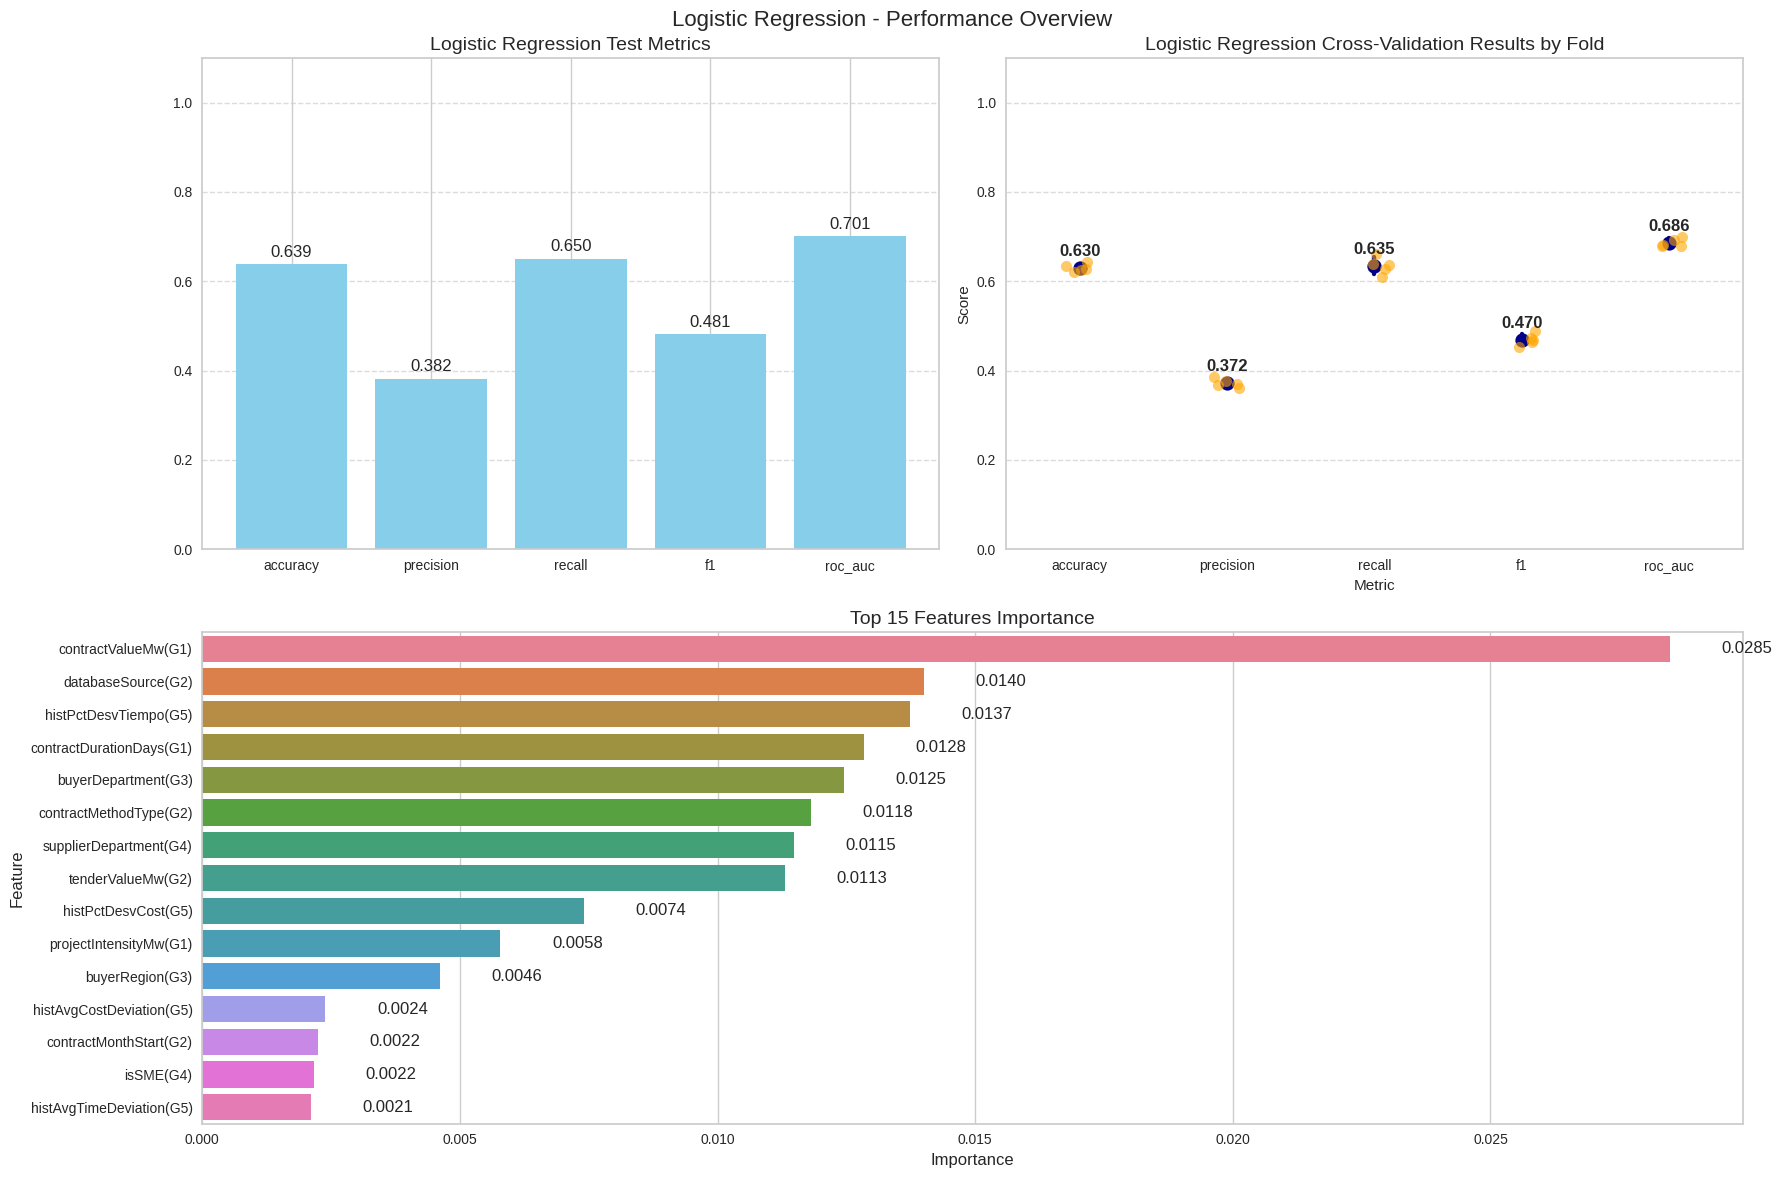

In [51]:
lr_model_s3 = LogisticRegression(random_state=42, max_iter=1000)
lr_results_s3 = train_evaluate_model(
    classifier=lr_model_s3,
    X_train=X_train_s3,
    y_train=y_train_s3,
    X_test=X_test_s3,
    y_test=y_test_s3,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="Logistic Regression",
    stage='S3',
    use_smote=True,
    perform_cv=True,
    cv=5,
    plot_results=True,
    n_top_features=15
)

### Ridge Model

Modelo Ridge entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== Ridge Performance Report =====

Test Set Metrics:
accuracy: 0.6351
precision: 0.3787
recall: 0.6487
f1: 0.4782

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.630984       0.00741        0.373544       0.008396     0.637017   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.014884  0.470931  0.010673      0.686252     0.008379  


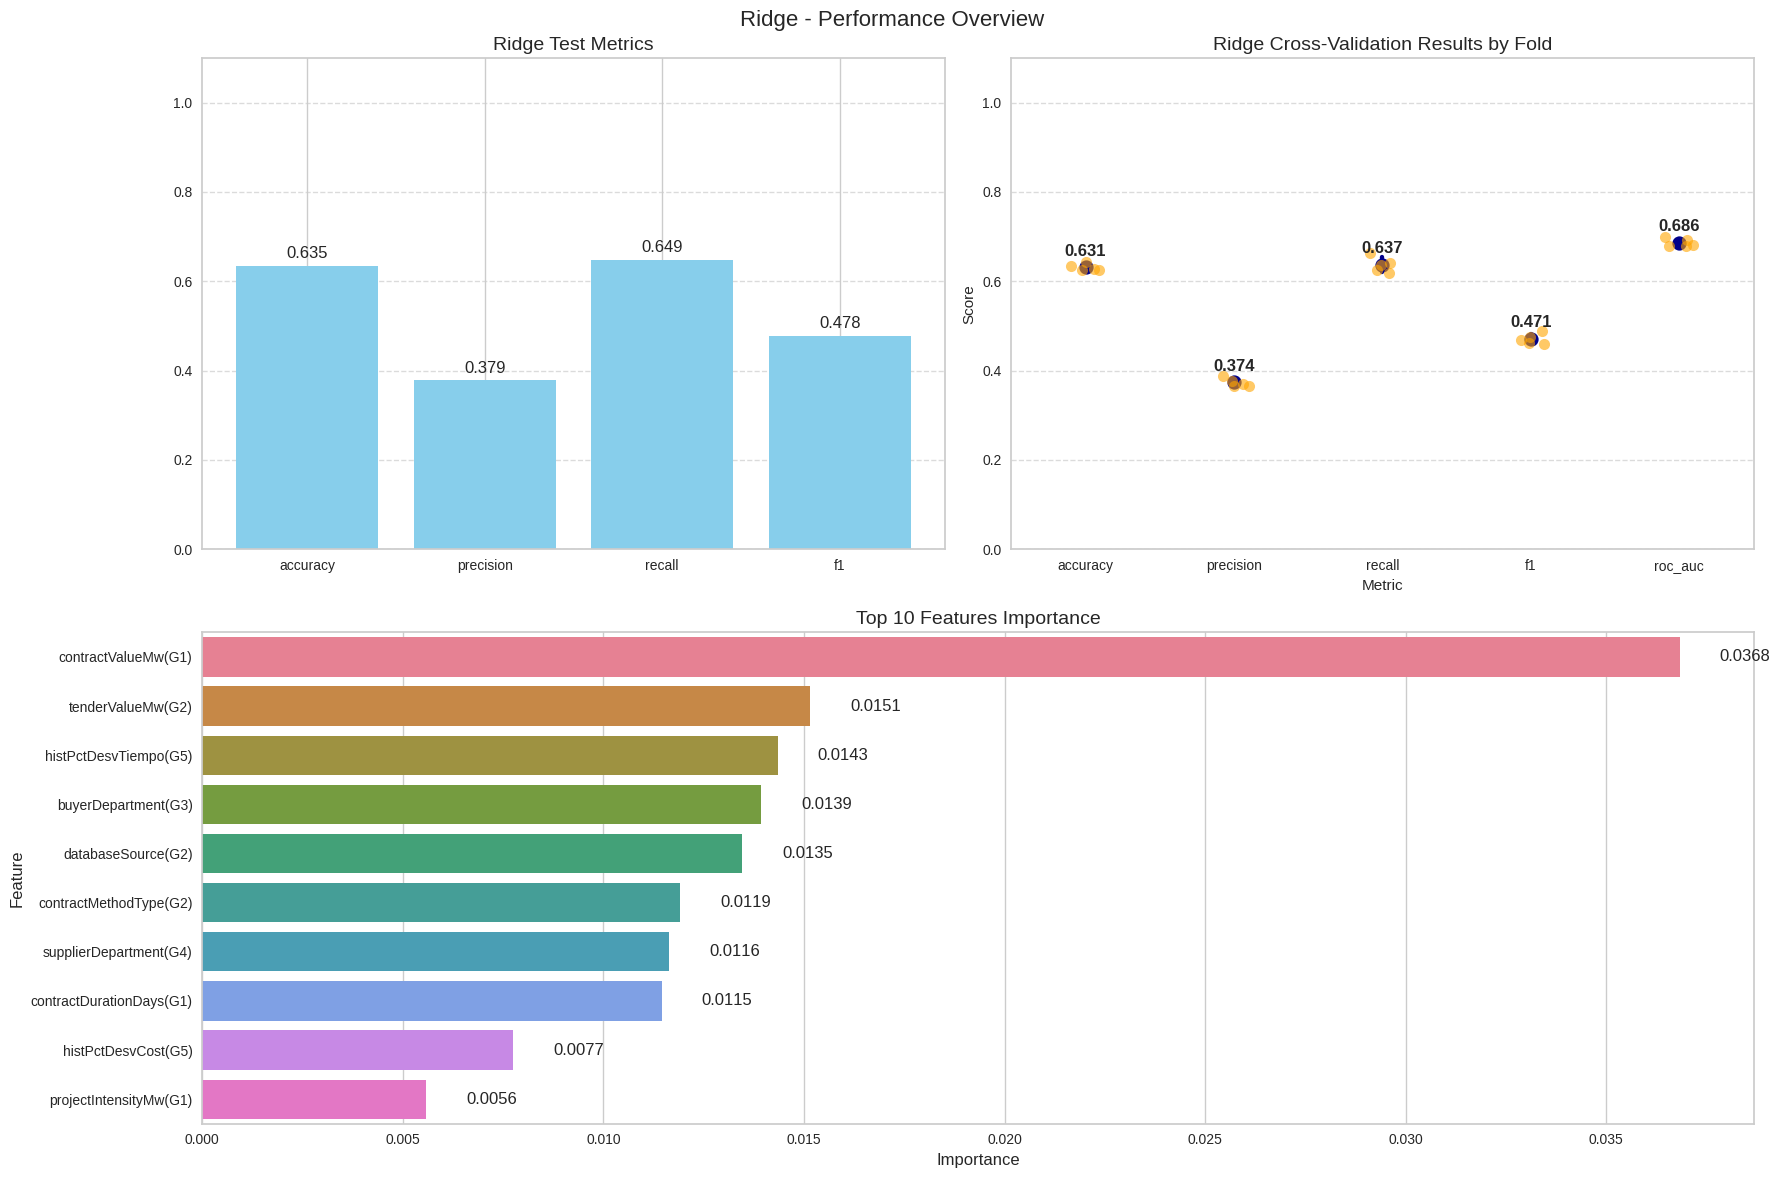

In [52]:
# Train and evaluate ridge model
ridge_model_s3 = RidgeClassifier(random_state=42)
ridge_results_s3 = train_evaluate_model(
    classifier=ridge_model_s3,
    X_train=X_train_s3,
    y_train=y_train_s3,
    X_test=X_test_s3,
    y_test=y_test_s3,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="Ridge",
    stage='S3',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### Random Forest

Modelo Random Forest entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== Random Forest Performance Report =====

Test Set Metrics:
accuracy: 0.7508
precision: 0.5280
recall: 0.3146
f1: 0.3943
roc_auc: 0.7294

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.745662      0.005438        0.511996       0.018171     0.305003   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.009179  0.382072  0.008618       0.71445     0.009492  


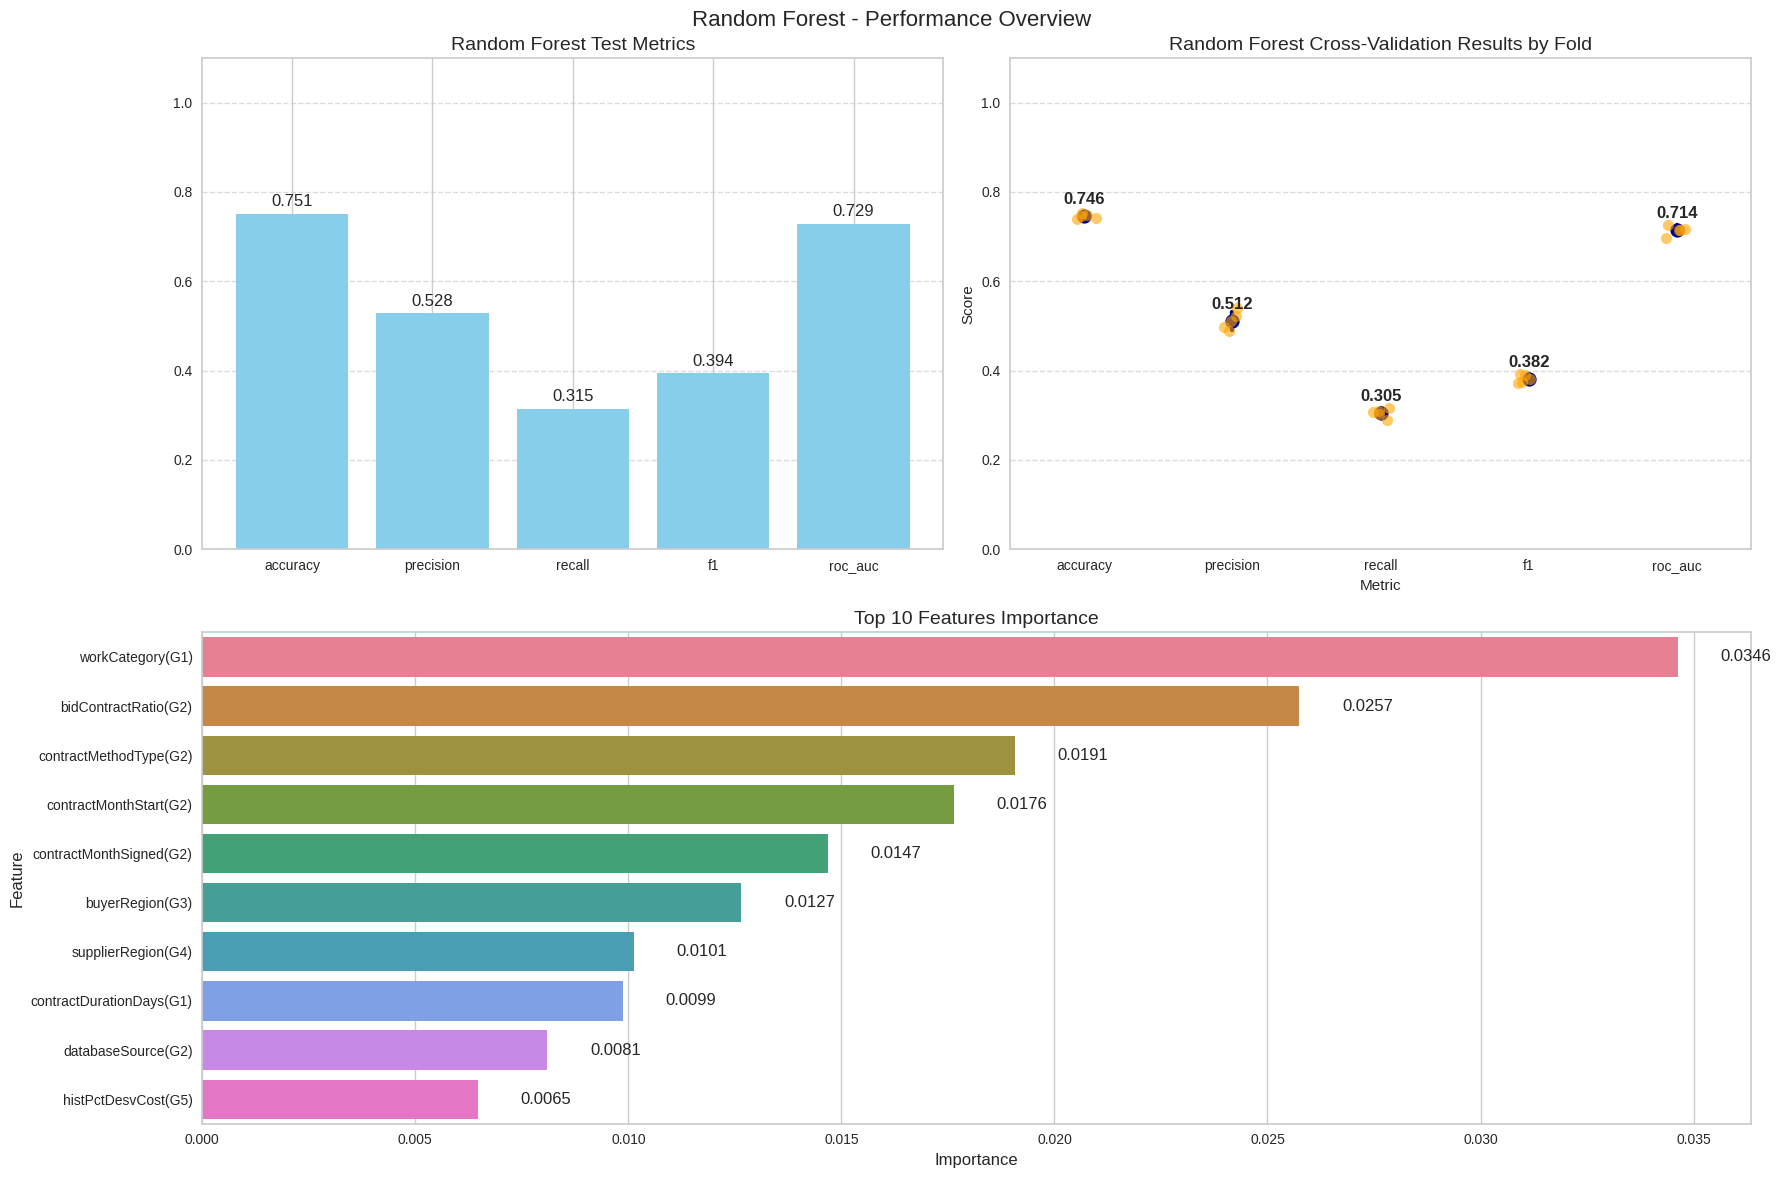

In [53]:
rf_model_s3 = RandomForestClassifier(random_state=42)
rf_results_s3 = train_evaluate_model(
    classifier=rf_model_s3,
    X_train=X_train_s3,
    y_train=y_train_s3,
    X_test=X_test_s3,
    y_test=y_test_s3,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="Random Forest",
    stage='S3',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### Extreme Gradient Boosting

Modelo XGBoost entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== XGBoost Performance Report =====

Test Set Metrics:
accuracy: 0.7530
precision: 0.5375
recall: 0.2989
f1: 0.3842
roc_auc: 0.7135

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.741463      0.004461        0.498147       0.015205     0.273032   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.005975  0.352552  0.003951      0.701327     0.006271  


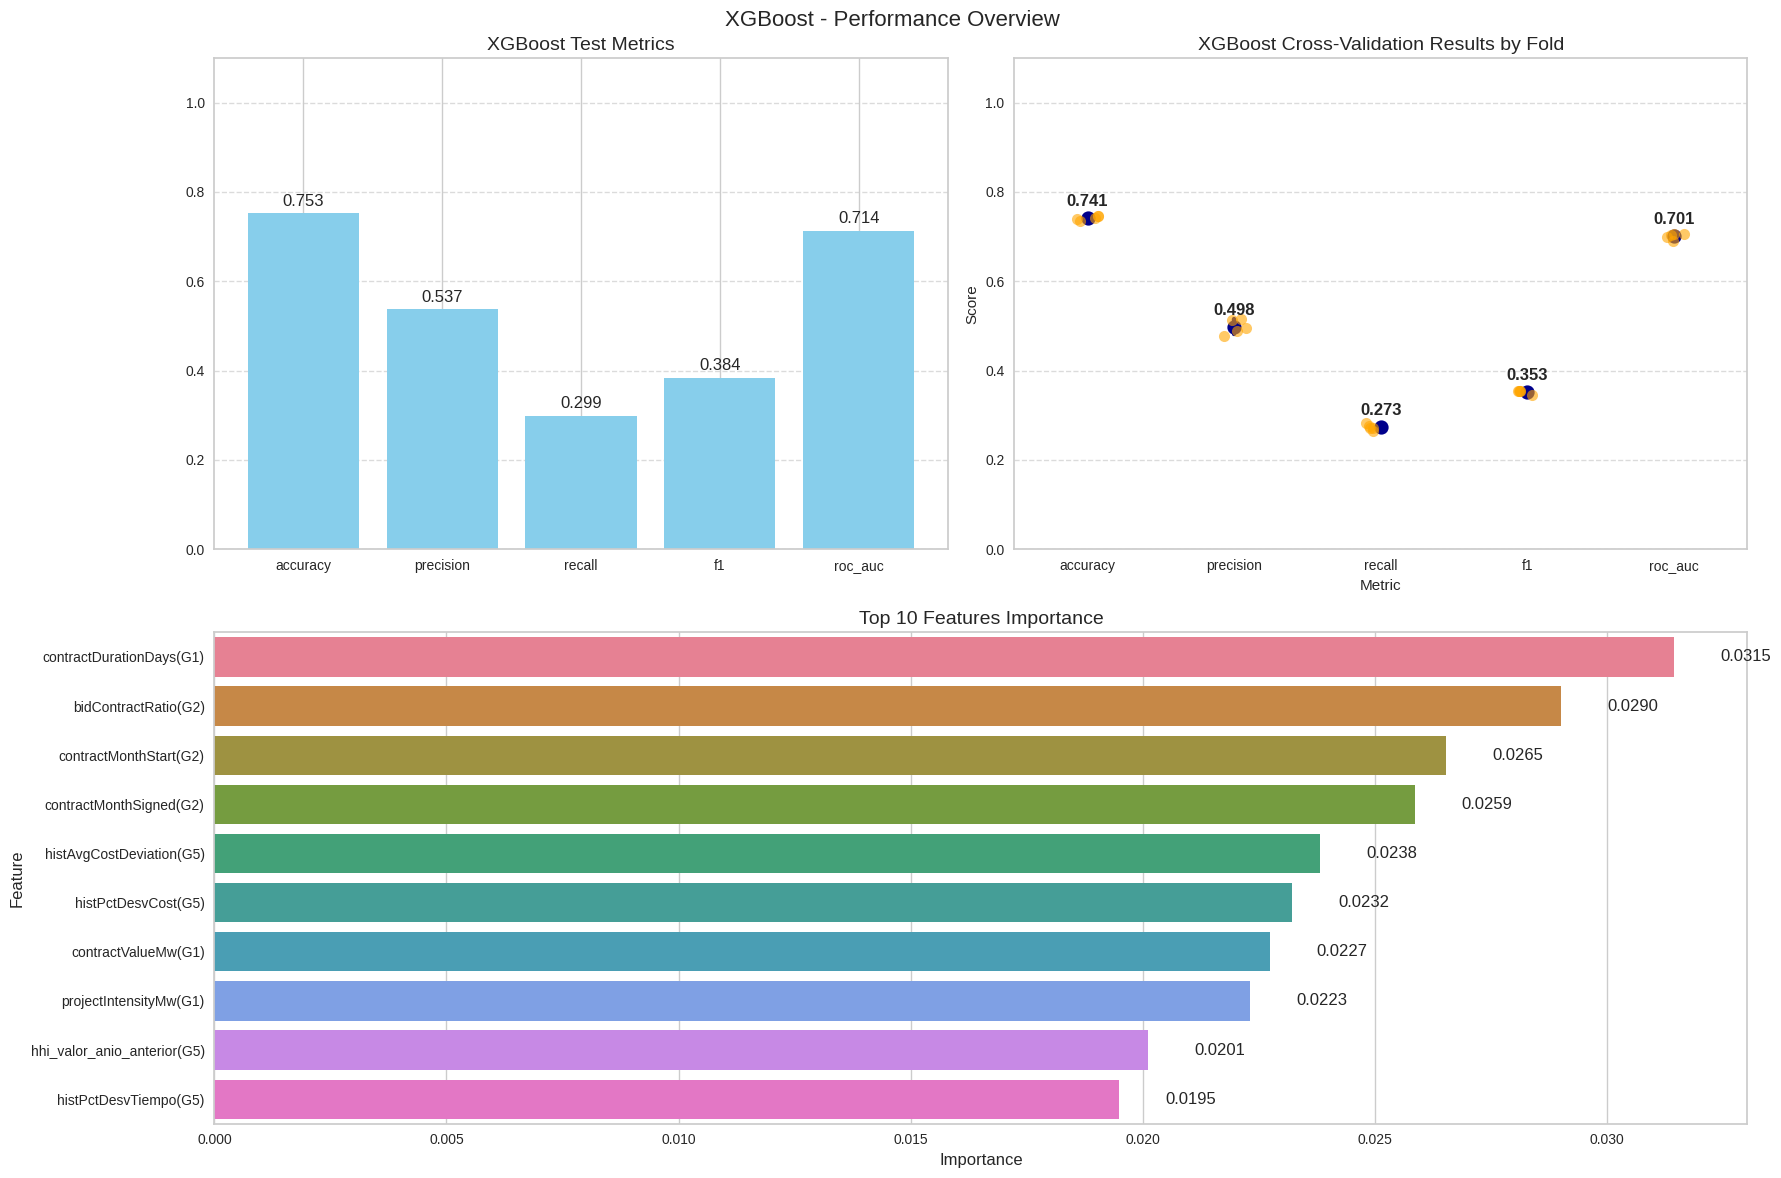

In [54]:
# Train and evaluate xgbModel
xgb_model_s3 = XGBClassifier(random_state=42)
xgb_results_s3 = train_evaluate_model(
    classifier=xgb_model_s3,
    X_train=X_train_s3,
    y_train=y_train_s3,
    X_test=X_test_s3,
    y_test=y_test_s3,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="XGBoost",
    stage='S3',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### Light Gradient Boosting

[LightGBM] [Info] Number of positive: 14497, number of negative: 14497
[LightGBM] [Info] Total Bins 22345
[LightGBM] [Info] Number of data points in the train set: 28994, number of used features: 154
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Modelo LightGBM entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}
[LightGBM] [Info] Number of positive: 11597, number of negative: 11597
[LightGBM] [Info] Total Bins 20982
[LightGBM] [Info] Number of data points in the train set: 23194, number of used features: 154
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 11597, number of negative: 11597
[LightGBM] [Info] Total Bins 20937
[LightGBM] [Info] Number of data points in the train set: 23194, number of used features: 154
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM]

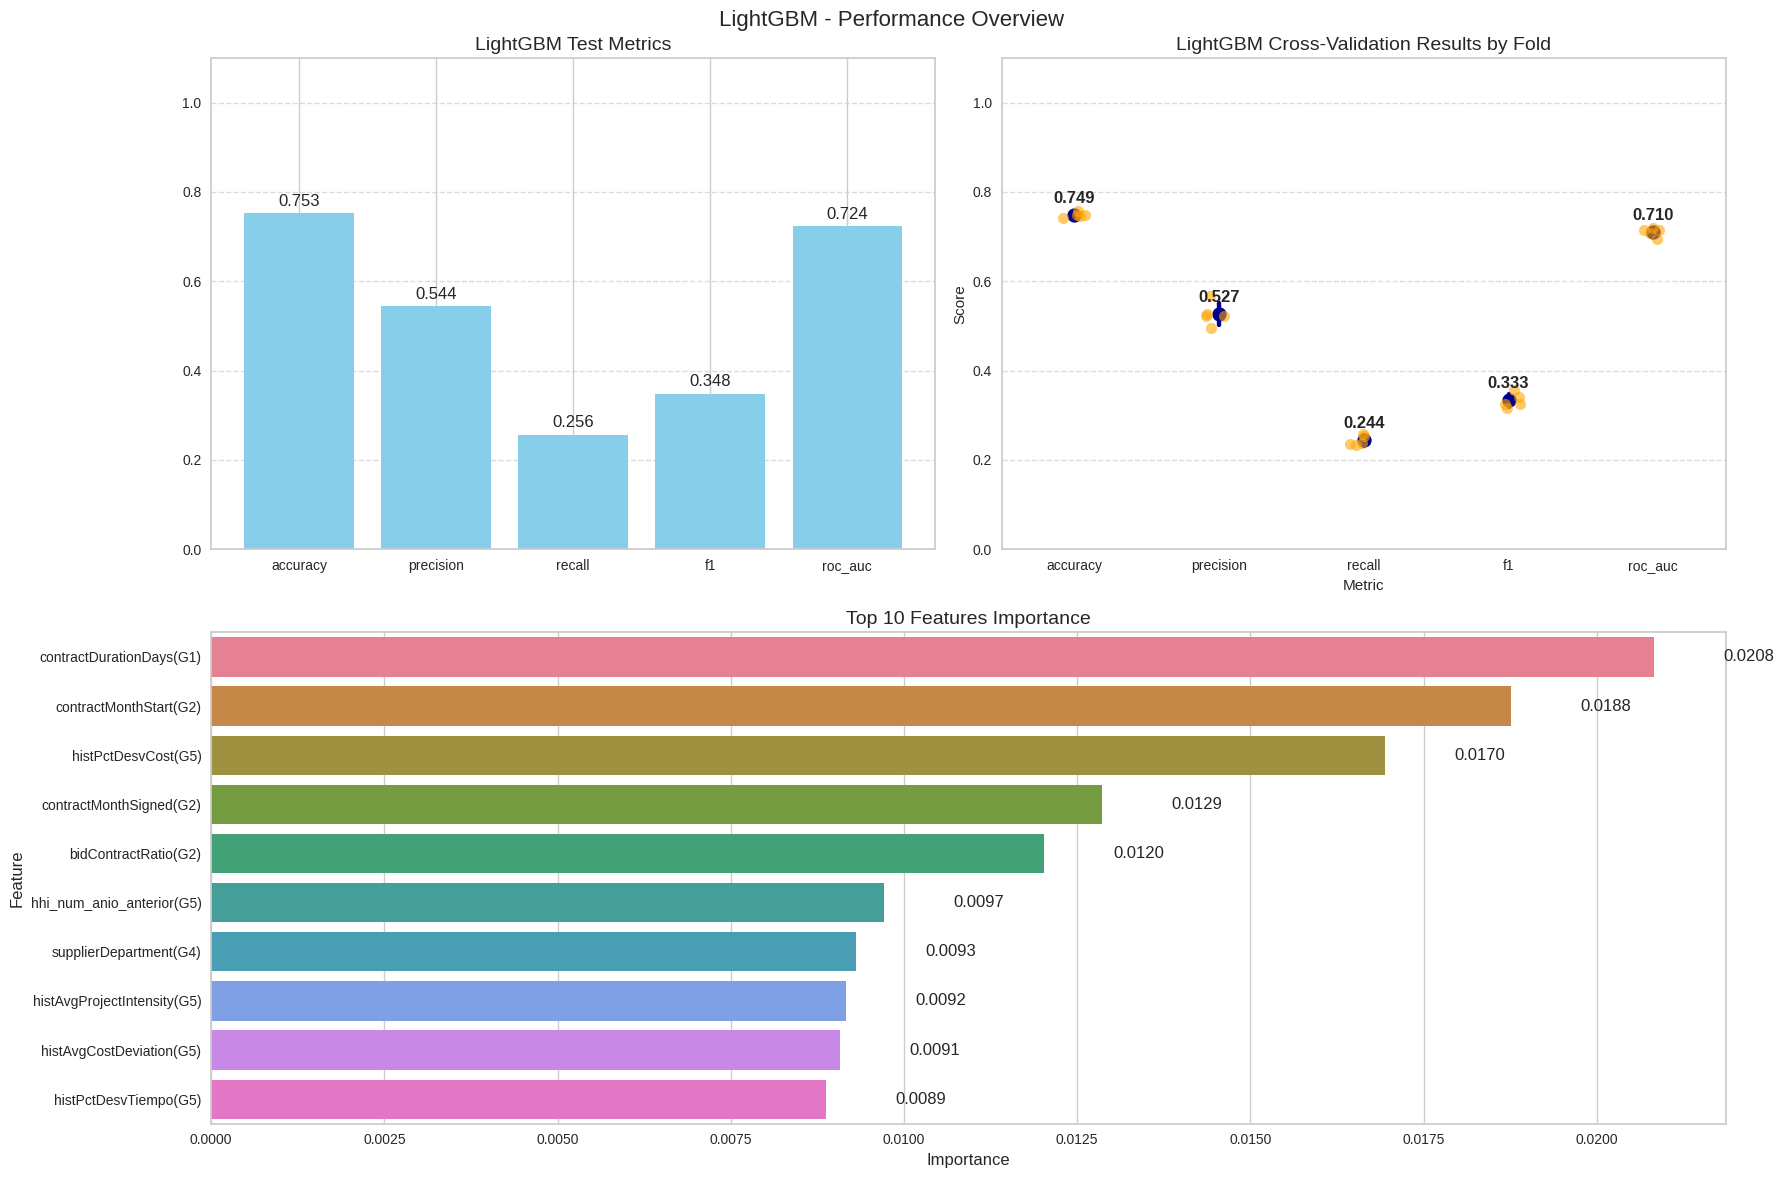

In [55]:
# Train and evaluate light gradient boosting
lgb_model_s3 = LGBMClassifier(random_state=42, force_row_wise=True)
lgb_results_s3 = train_evaluate_model(
    classifier=lgb_model_s3,
    X_train=X_train_s3,
    y_train=y_train_s3,
    X_test=X_test_s3,
    y_test=y_test_s3,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="LightGBM",
    stage='S3',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### K Nearest Neighbors

In [56]:
# Train and Evaluate KNN
knn_model_s3 = KNeighborsClassifier()
knn_results_s3 = train_evaluate_model(
    classifier=knn_model_s3,
    X_train=X_train_s3,
    y_train=y_train_s3,
    X_test=X_test_s3,
    y_test=y_test_s3,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="KNN",
    stage='S3',
    use_smote=True,
    perform_cv=True,
    plot_results=False
)

Modelo KNN entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== KNN Performance Report =====

Test Set Metrics:
accuracy: 0.5989
precision: 0.3522
recall: 0.6627
f1: 0.4600
roc_auc: 0.6643

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0        0.59018      0.007944        0.347669       0.004753     0.672159   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.008734  0.458234  0.003403      0.654047     0.005359  


### Suport Vector Machine

In [57]:
# Train and evaluate SVC model
svc_model_s3 = SVC(random_state=42)
svc_results_s3 = train_evaluate_model(
    classifier=svc_model_s3,
    X_train=X_train_s3,
    y_train=y_train_s3,
    X_test=X_test_s3,
    y_test=y_test_s3,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="SVC",
    stage='S3',
    use_smote=True,
    perform_cv=True,
    plot_results=False
)

Modelo SVC entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== SVC Performance Report =====

Test Set Metrics:
accuracy: 0.6524
precision: 0.3889
recall: 0.6098
f1: 0.4749

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.660216       0.00557        0.396384       0.004789     0.607423   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.015619  0.479607  0.005132      0.696004     0.006372  


### Neural Network

In [58]:
# Train Neural Network
nn_model_s3 = MLPClassifier(random_state=42, max_iter=1000)
nn_results_s3 = train_evaluate_model(
    classifier=nn_model_s3,
    X_train=X_train_s3,
    y_train=y_train_s3,
    X_test=X_test_s3,
    y_test=y_test_s3,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="Neural Network",
    stage='S3',
    use_smote=True,
    perform_cv=True,
    plot_results=False
)

Modelo Neural Network entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== Neural Network Performance Report =====

Test Set Metrics:
accuracy: 0.6701
precision: 0.3741
recall: 0.4157
f1: 0.3938
roc_auc: 0.6383

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.674398      0.006226        0.373468       0.012127      0.38861   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.022146  0.380748  0.016205       0.63835     0.008933  


### Consolidate results

In [59]:
# Consolidate scores of all models
lr_results_s3['metrics'].update({'Model': 'Logit'})
lr_results_s3['metrics'].update({'Stage': 'S3'})
lr_results_s3_df = pd.DataFrame(lr_results_s3['metrics'], index=[0])

ridge_results_s3['metrics'].update({'Model': 'Ridge'})
ridge_results_s3['metrics'].update({'Stage': 'S3'})
ridge_results_s3_df = pd.DataFrame(ridge_results_s3['metrics'], index=[0])

rf_results_s3['metrics'].update({'Model': 'Random Forest'})
rf_results_s3['metrics'].update({'Stage': 'S3'})
rf_results_s3_df = pd.DataFrame(rf_results_s3['metrics'], index=[0])

xgb_results_s3['metrics'].update({'Model': 'XGBoost'})
xgb_results_s3['metrics'].update({'Stage': 'S3'})
xgb_results_s3_df = pd.DataFrame(xgb_results_s3['metrics'], index=[0])

lgb_results_s3['metrics'].update({'Model': 'LightGBM'})
lgb_results_s3['metrics'].update({'Stage': 'S3'})
lgb_results_s3_df = pd.DataFrame(lgb_results_s3['metrics'], index=[0])

knn_results_s3['metrics'].update({'Model': 'KNN'})
knn_results_s3['metrics'].update({'Stage': 'S3'})
knn_results_s3_df = pd.DataFrame(knn_results_s3['metrics'], index=[0])

svc_results_s3['metrics'].update({'Model': 'SVC'})
svc_results_s3['metrics'].update({'Stage': 'S3'})
svc_results_s3_df = pd.DataFrame(svc_results_s3['metrics'], index=[0])

nn_results_s3['metrics'].update({'Model': 'Neural Network'})
nn_results_s3['metrics'].update({'Stage': 'S3'})
nn_results_s3_df = pd.DataFrame(nn_results_s3['metrics'], index=[0])

# consolidate all data frame
scores_df_s3 = pd.concat([lr_results_s3_df,
                       ridge_results_s3_df,
                       rf_results_s3_df,
                       xgb_results_s3_df,
                       lgb_results_s3_df,
                       knn_results_s3_df,
                       svc_results_s3_df,
                       nn_results_s3_df],
                      ignore_index=True)

# Calcular la media para las columnas numéricas
mean_values = scores_df_s3.select_dtypes(include=['number']).mean()
mean_row = pd.Series({'Stage': 'S3', 'Model': 'Mean'})
for col in mean_values.index:
    mean_row[col] = mean_values[col]

# Calcular la desviación estándar para las columnas numéricas
std_values = scores_df_s3.select_dtypes(include=['number']).std()
std_row = pd.Series({'Stage': 'S3', 'Model': 'Std'})
for col in std_values.index:
    std_row[col] = std_values[col]

# Añadir las filas al DataFrame
scores_df_s3 = pd.concat([scores_df_s3, pd.DataFrame([mean_row, std_row])], ignore_index=True)
print((scores_df_s3))

   accuracy  precision    recall        f1   roc_auc           Model Stage
0  0.638557   0.381873  0.650139  0.481139  0.700590           Logit    S3
1  0.635093   0.378685  0.648749  0.478224       NaN           Ridge    S3
2  0.750836   0.527994  0.314643  0.394309  0.729356   Random Forest    S3
3  0.752986   0.537500  0.298888  0.384157  0.713520         XGBoost    S3
4  0.752867   0.543756  0.256256  0.348346  0.723874        LightGBM    S3
5  0.598901   0.352217  0.662651  0.459955  0.664323             KNN    S3
6  0.652413   0.388889  0.609824  0.474919       NaN             SVC    S3
7  0.670091   0.374062  0.415663  0.393766  0.638263  Neural Network    S3
8  0.681468   0.435622  0.482101  0.426852  0.694988            Mean    S3
9  0.061884   0.084232  0.178065  0.052279  0.036190             Std    S3


In [60]:
pd.concat([scores_df_s1, scores_df_s2,scores_df_s3]).groupby(['Stage','Model']).mean().to_latex(index=True,
                  #formatters={"name": str.upper},
                  float_format="{:.4f}".format,)

'\\begin{tabular}{llrrrrr}\n\\toprule\n &  & accuracy & precision & recall & f1 & roc_auc \\\\\nStage & Model &  &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{10}{*}{S1} & KNN & 0.5852 & 0.3109 & 0.5009 & 0.3837 & 0.5755 \\\\\n & LightGBM & 0.7182 & 0.4040 & 0.1960 & 0.2640 & 0.6090 \\\\\n & Logit & 0.6012 & 0.3330 & 0.5454 & 0.4135 & 0.6164 \\\\\n & Mean & 0.6423 & 0.3466 & 0.3981 & 0.3540 & 0.5943 \\\\\n & Neural Network & 0.6217 & 0.3158 & 0.4008 & 0.3533 & 0.5608 \\\\\n & Random Forest & 0.6887 & 0.3629 & 0.2748 & 0.3128 & 0.6034 \\\\\n & Ridge & 0.5999 & 0.3311 & 0.5412 & 0.4108 & NaN \\\\\n & SVC & 0.6220 & 0.3360 & 0.4782 & 0.3947 & NaN \\\\\n & Std & 0.0521 & 0.0325 & 0.1404 & 0.0562 & 0.0215 \\\\\n & XGBoost & 0.7016 & 0.3791 & 0.2470 & 0.2991 & 0.6006 \\\\\n\\cline{1-7}\n\\multirow[t]{10}{*}{S2} & KNN & 0.5671 & 0.3189 & 0.5982 & 0.4160 & 0.6035 \\\\\n & LightGBM & 0.7426 & 0.5017 & 0.2048 & 0.2909 & 0.6854 \\\\\n & Logit & 0.6154 & 0.3636 & 0.6557 & 0.4678 & 0.6803 \\\\\n & Mea

## Stage 4: All Variables

In [61]:
# Separate features and target
X4 = df[projectsColumns + contractColumns + buyerColumns + supplierColumns + buyerIndicators + terridataColumns]
y4 = df['haveCostDeviation(G7)']

In [62]:
# select categorical columns
categoricalColumns = X4.select_dtypes(include=['object']).columns
# select numerical columns
numericColumns = X4.select_dtypes(include=['int64', 'float64']).columns

In [63]:
# Split data into training and testing sets
X_train_s4, X_test_s4, y_train_s4, y_test_s4 = train_test_split(X4, y4, test_size=0.3, random_state=42, stratify=y4)

### Logistic Regression

Modelo Logistic Regression entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== Logistic Regression Performance Report =====

Test Set Metrics:
accuracy: 0.6393
precision: 0.3820
recall: 0.6464
f1: 0.4802
roc_auc: 0.7042

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.631291      0.007069        0.375087       0.007843     0.645753   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.015342  0.474523  0.010122      0.690441     0.007931  


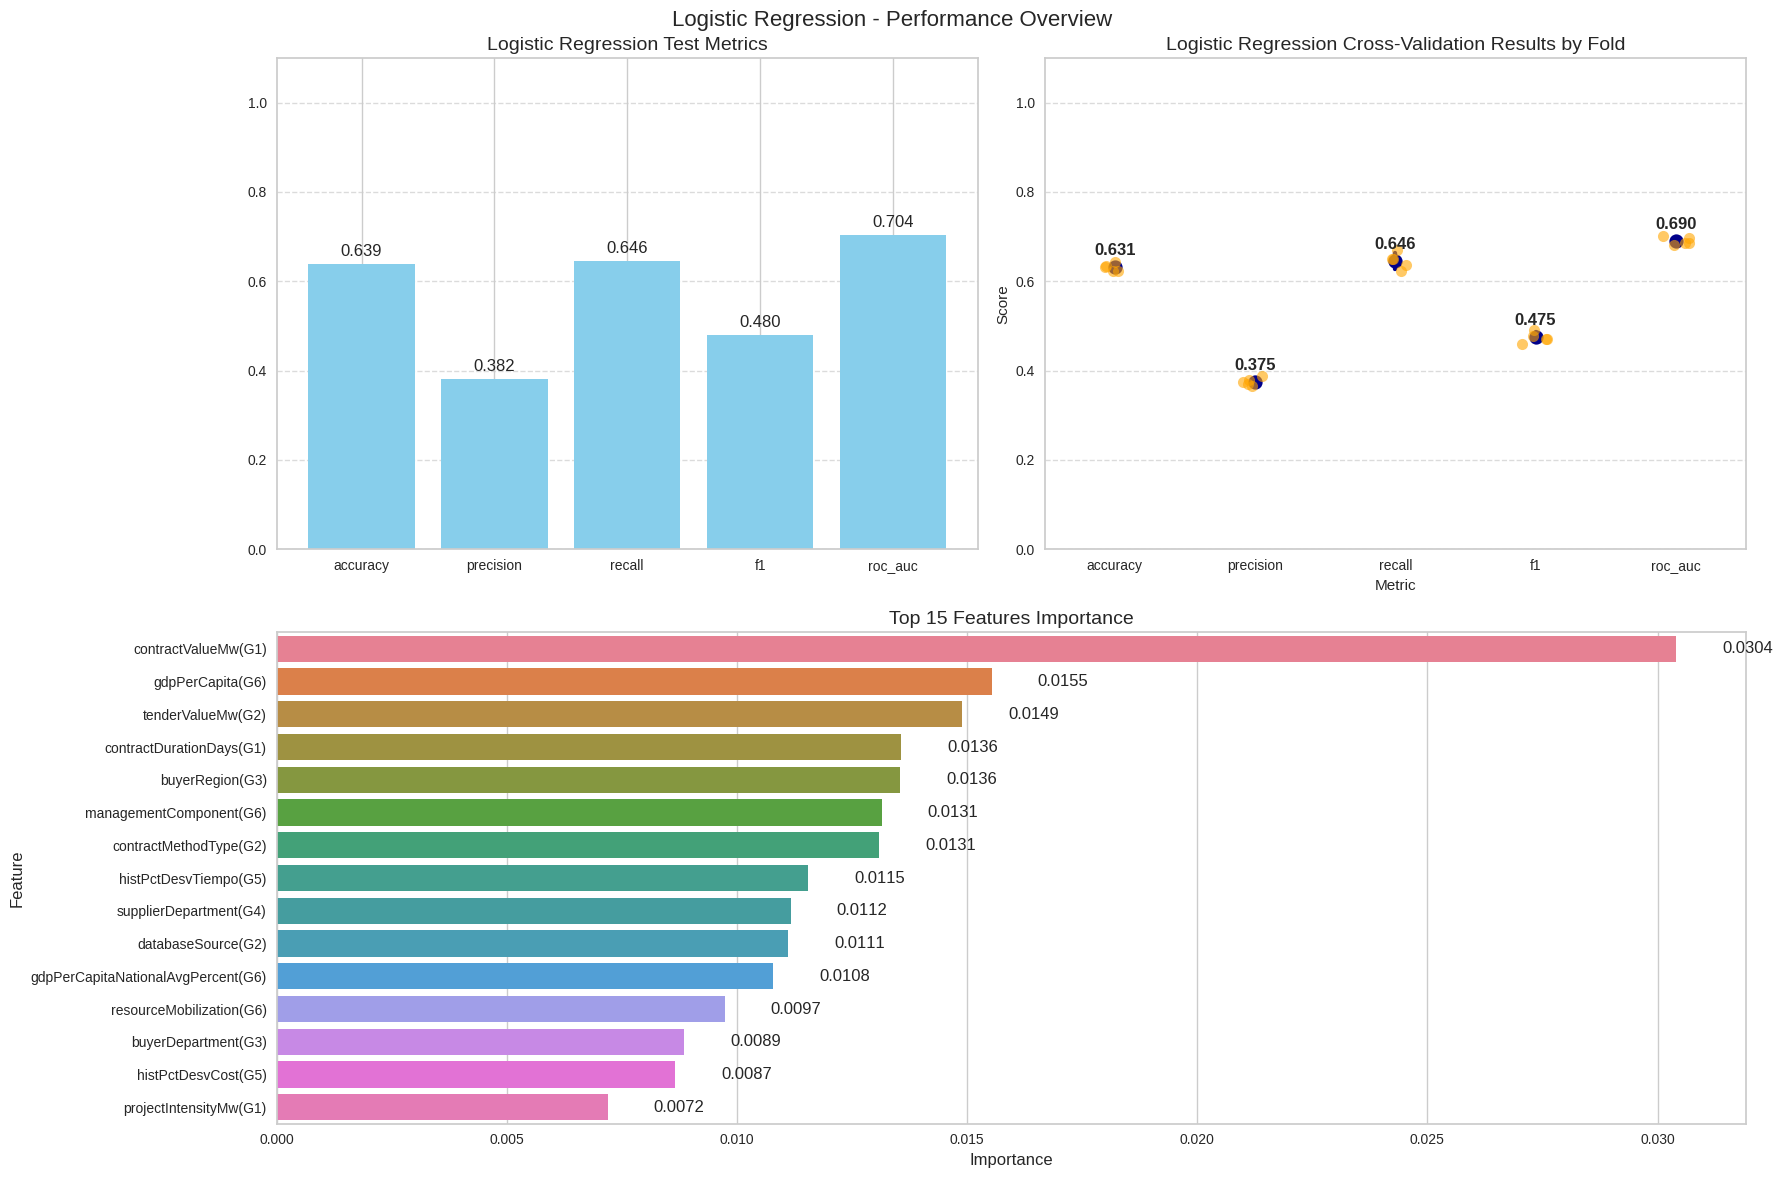

In [64]:
lr_model_s4 = LogisticRegression(random_state=42, max_iter=1000)
lr_results_s4 = train_evaluate_model(
    classifier=lr_model_s4,
    X_train=X_train_s4,
    y_train=y_train_s4,
    X_test=X_test_s4,
    y_test=y_test_s4,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="Logistic Regression",
    stage='S4',
    use_smote=True,
    perform_cv=True,
    cv=5,
    plot_results=True,
    n_top_features=15
)

### Ridge Model

Modelo Ridge entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== Ridge Performance Report =====

Test Set Metrics:
accuracy: 0.6371
precision: 0.3802
recall: 0.6474
f1: 0.4791

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.630369      0.006497        0.374433       0.007008     0.646546   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.013802  0.474211  0.008927      0.690437     0.007874  


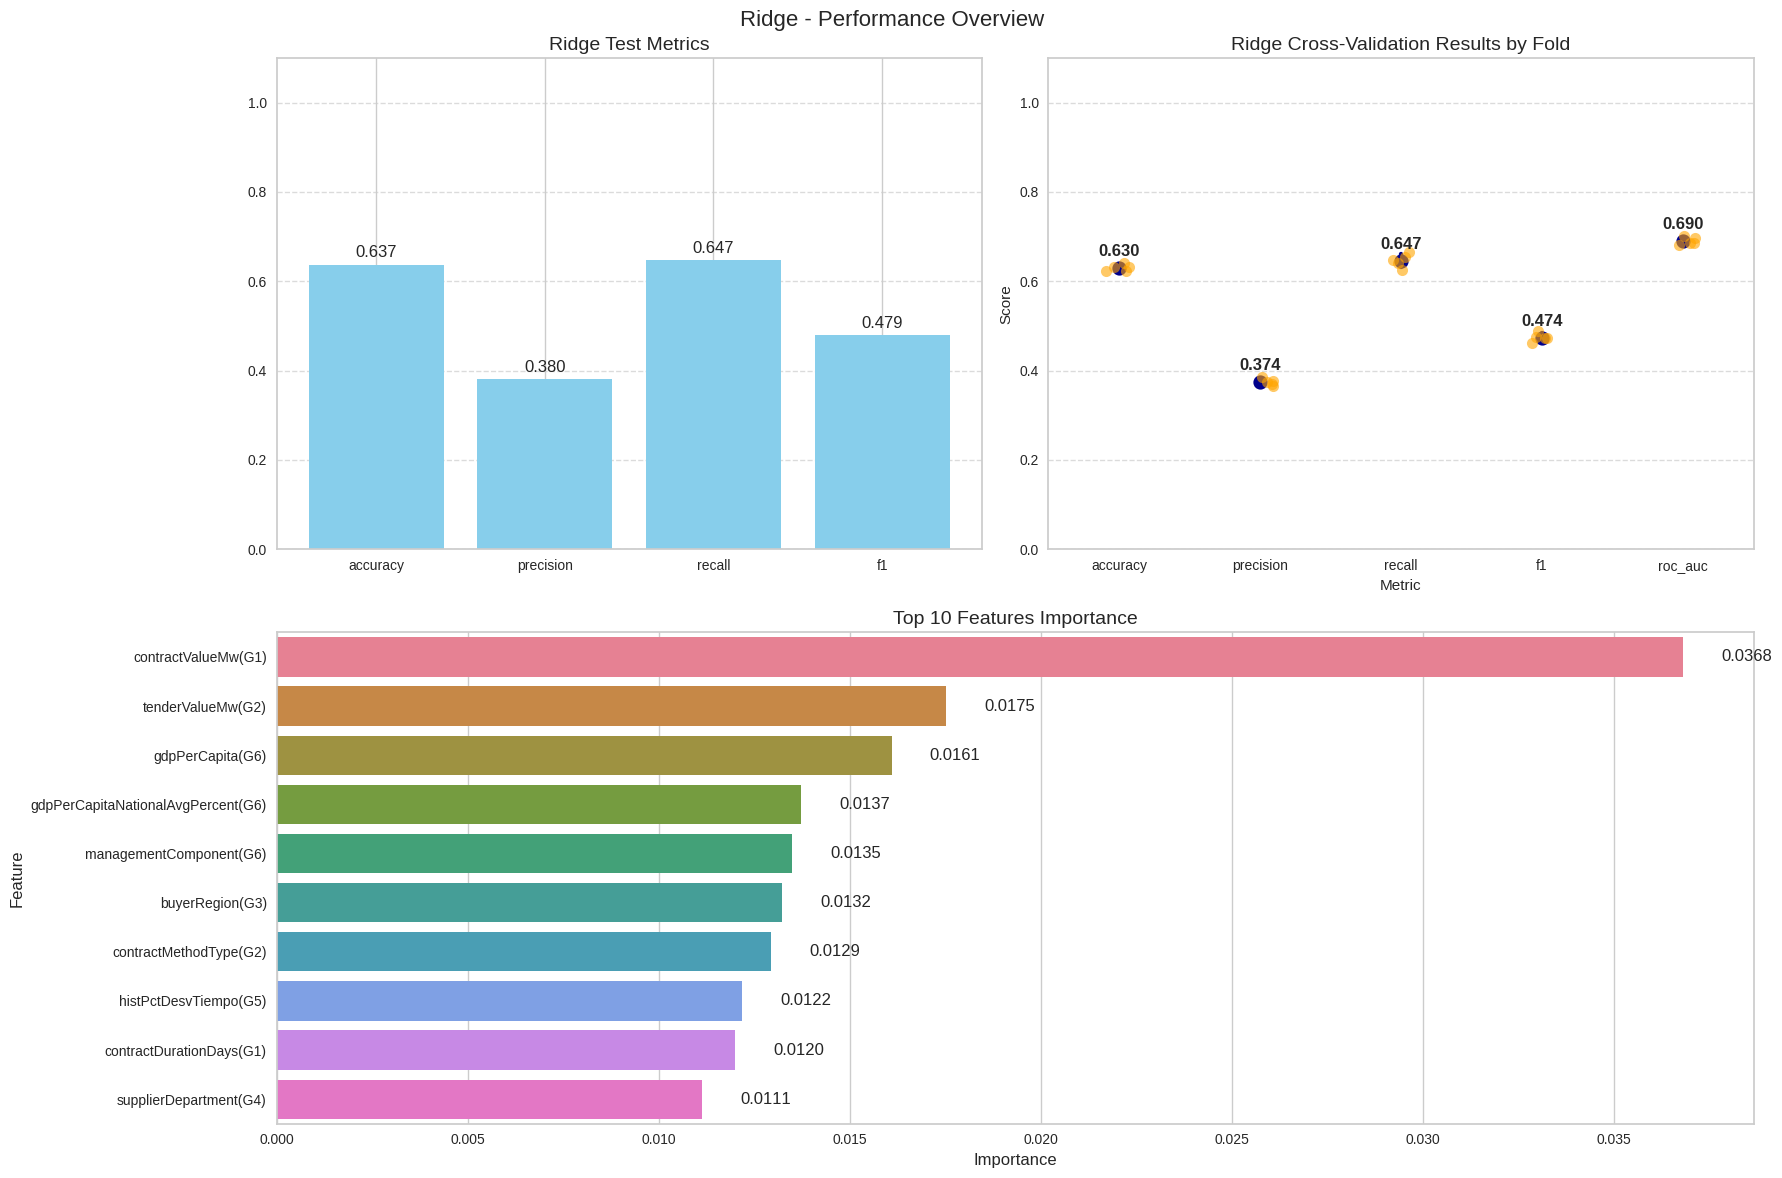

In [65]:
# Train and evaluate ridge model
ridge_model_s4 = RidgeClassifier(random_state=42)
ridge_results_s4 = train_evaluate_model(
    classifier=ridge_model_s4,
    X_train=X_train_s4,
    y_train=y_train_s4,
    X_test=X_test_s4,
    y_test=y_test_s4,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="Ridge",
    stage='S4',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### Random Forest

Modelo Random Forest entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== Random Forest Performance Report =====

Test Set Metrics:
accuracy: 0.7538
precision: 0.5373
recall: 0.3239
f1: 0.4042
roc_auc: 0.7388

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.750627      0.003512        0.527831       0.012192     0.314536   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.011927  0.393971  0.009447      0.722599     0.007709  


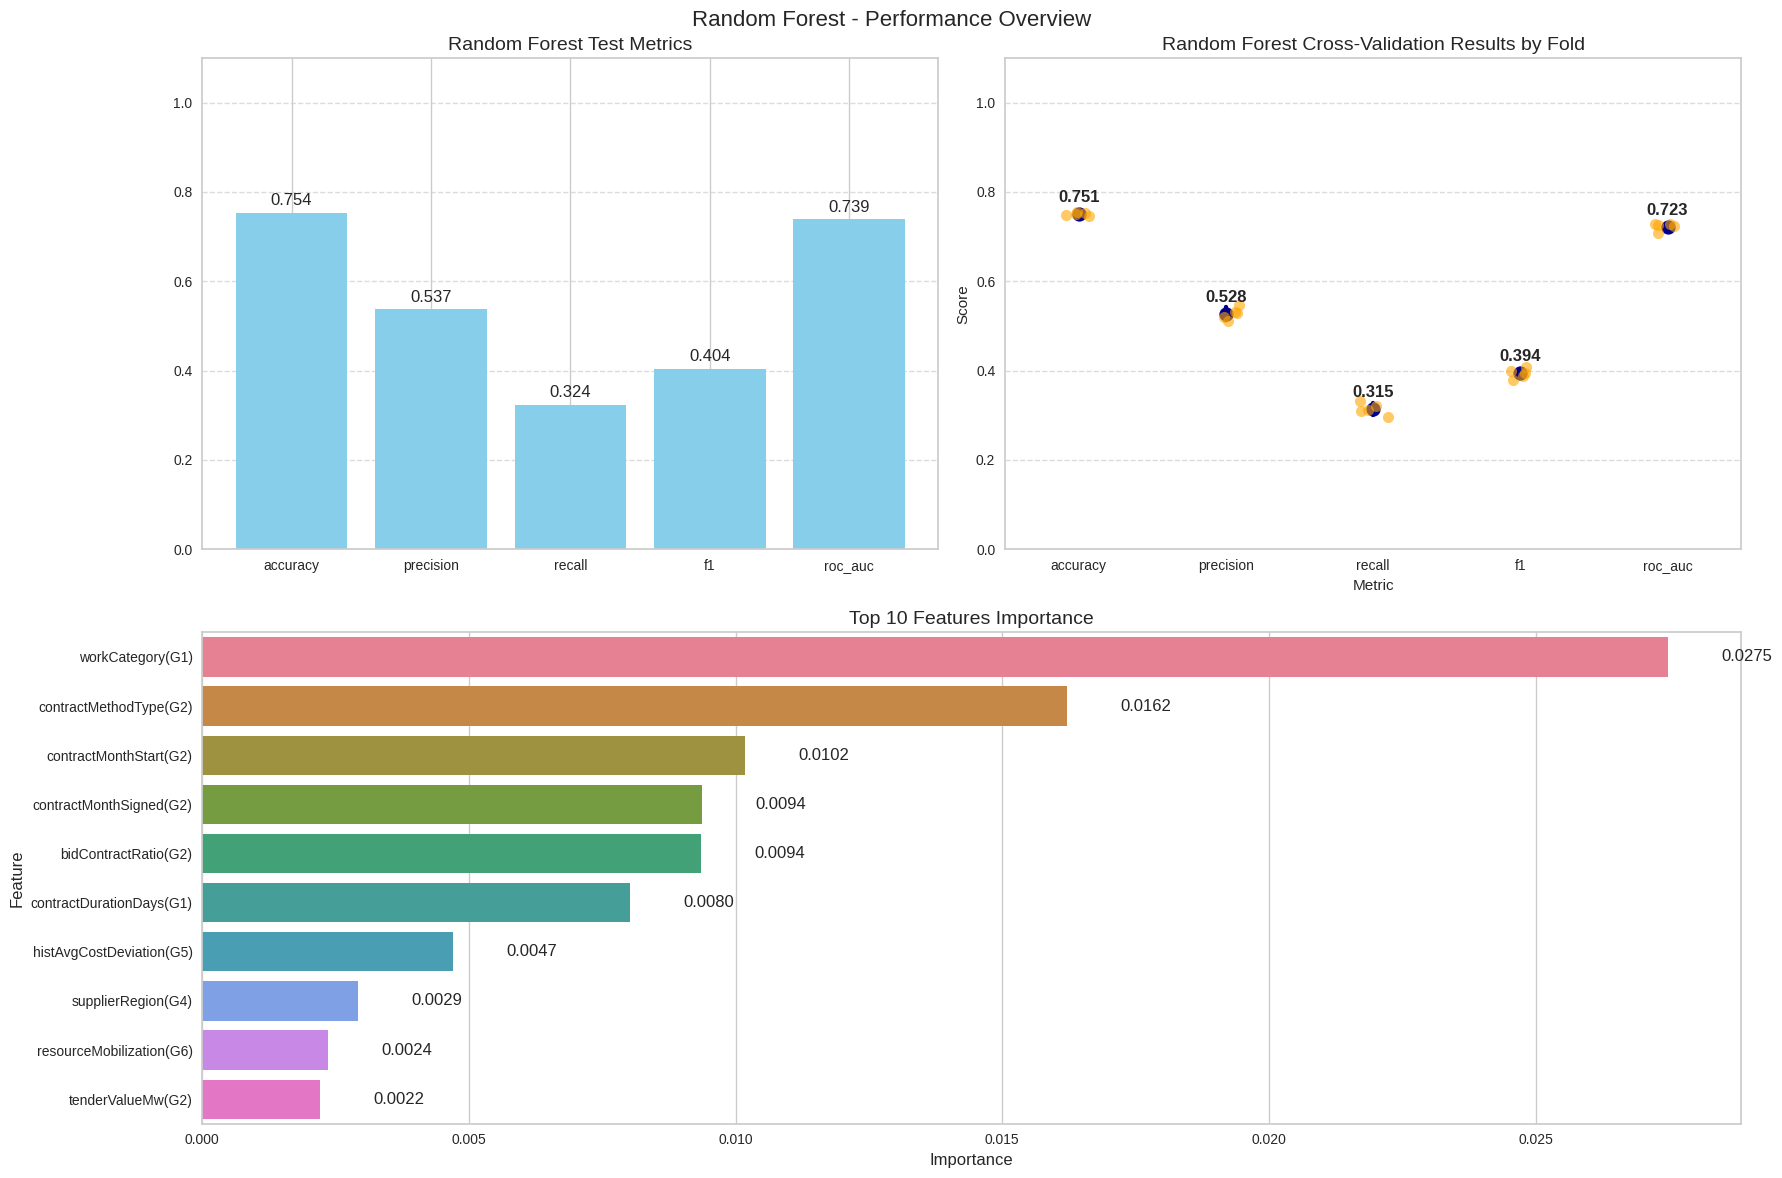

In [66]:
rf_model_s4 = RandomForestClassifier(random_state=42)
rf_results_s4 = train_evaluate_model(
    classifier=rf_model_s4,
    X_train=X_train_s4,
    y_train=y_train_s4,
    X_test=X_test_s4,
    y_test=y_test_s4,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="Random Forest",
    stage='S4',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### Extreme Gradient Boosting

Modelo XGBoost entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== XGBoost Performance Report =====

Test Set Metrics:
accuracy: 0.7506
precision: 0.5272
recall: 0.3146
f1: 0.3941
roc_auc: 0.7238

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.742948      0.005528        0.502976       0.017981     0.299047   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.013051  0.374864  0.012534       0.70969     0.008153  


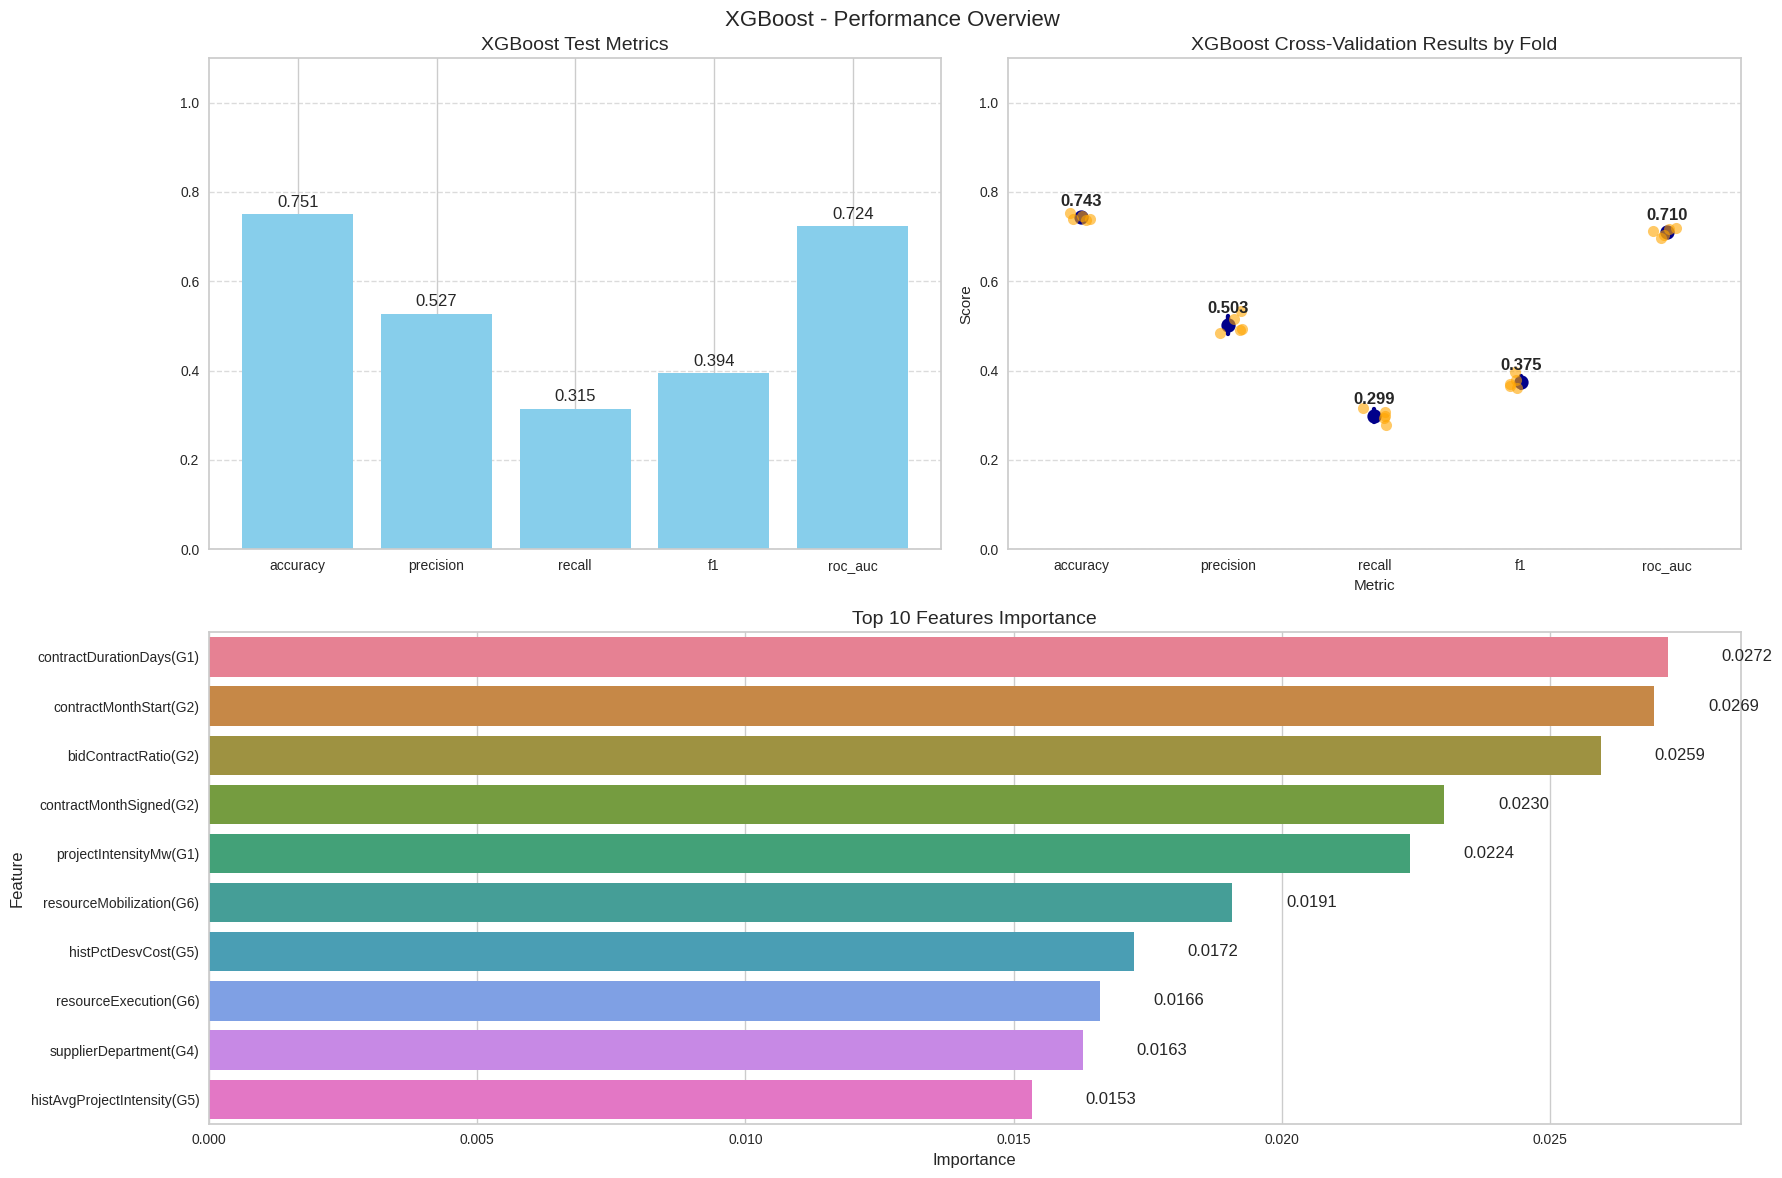

In [67]:
# Train and evaluate xgbModel
xgb_model_s4 = XGBClassifier(random_state=42)
xgb_results_s4 = train_evaluate_model(
    classifier=xgb_model_s4,
    X_train=X_train_s4,
    y_train=y_train_s4,
    X_test=X_test_s4,
    y_test=y_test_s4,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="XGBoost",
    stage='S4',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### Light Gradient Boosting

[LightGBM] [Info] Number of positive: 14497, number of negative: 14497
[LightGBM] [Info] Total Bins 24106
[LightGBM] [Info] Number of data points in the train set: 28994, number of used features: 179
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Modelo LightGBM entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}
[LightGBM] [Info] Number of positive: 11597, number of negative: 11597
[LightGBM] [Info] Total Bins 23098
[LightGBM] [Info] Number of data points in the train set: 23194, number of used features: 176
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 11597, number of negative: 11597
[LightGBM] [Info] Total Bins 22979
[LightGBM] [Info] Number of data points in the train set: 23194, number of used features: 178
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM]

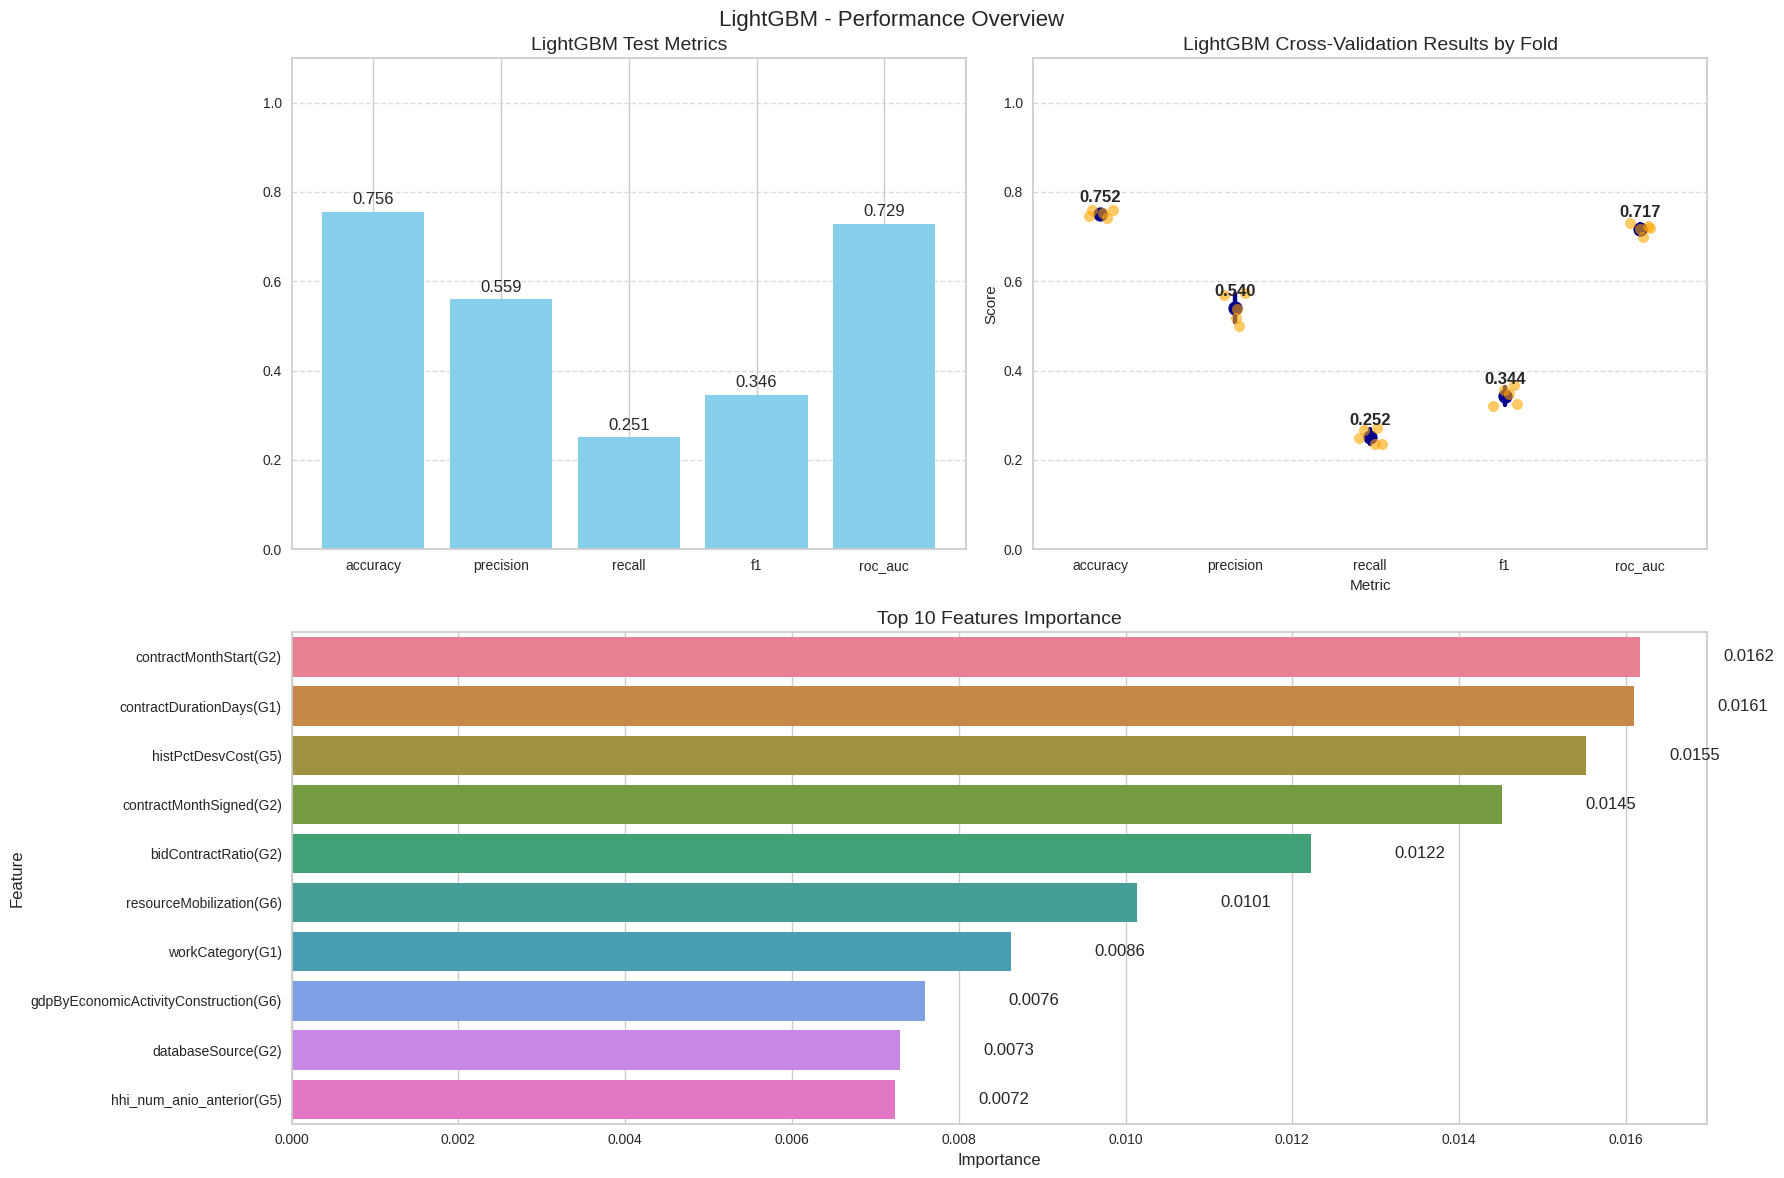

In [68]:
# Train and evaluate light gradient boosting
lgb_model_s4 = LGBMClassifier(random_state=42, force_row_wise=True)
lgb_results_s4 = train_evaluate_model(
    classifier=lgb_model_s4,
    X_train=X_train_s4,
    y_train=y_train_s4,
    X_test=X_test_s4,
    y_test=y_test_s4,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="LightGBM",
    stage='S4',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### K Nearest Neighbors

In [69]:
# Train and Evaluate KNN
knn_model_s4 = KNeighborsClassifier()
knn_results_s4 = train_evaluate_model(
    classifier=knn_model_s4,
    X_train=X_train_s4,
    y_train=y_train_s4,
    X_test=X_test_s4,
    y_test=y_test_s4,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="KNN",
    stage='S4',
    use_smote=True,
    perform_cv=True,
    plot_results=False
)

Modelo KNN entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== KNN Performance Report =====

Test Set Metrics:
accuracy: 0.6187
precision: 0.3698
recall: 0.6807
f1: 0.4793
roc_auc: 0.6875

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.613065      0.010487        0.365079       0.007121     0.676129   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.009761  0.474038  0.004643      0.677684     0.003625  


### Suport Vector Machine

In [70]:
# Train and evaluate SVC model
svc_model_s4 = SVC(random_state=42)
svc_results_s4 = train_evaluate_model(
    classifier=svc_model_s4,
    X_train=X_train_s4,
    y_train=y_train_s4,
    X_test=X_test_s4,
    y_test=y_test_s4,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="SVC",
    stage='S4',
    use_smote=True,
    perform_cv=True,
    plot_results=False
)

Modelo SVC entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== SVC Performance Report =====

Test Set Metrics:
accuracy: 0.6564
precision: 0.3924
recall: 0.6075
f1: 0.4768

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.661444      0.009469        0.397944        0.00912     0.608418   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.005245  0.481058  0.004925      0.697615     0.008487  


### Neural Network

Modelo Neural Network entrenado exitosamente.
Distribución de clases en conjunto de entrenamiento: {np.int64(0): np.int64(14497), np.int64(1): np.int64(5036)}

===== Neural Network Performance Report =====

Test Set Metrics:
accuracy: 0.6851
precision: 0.3927
recall: 0.4055
f1: 0.3990
roc_auc: 0.6528

Cross-Validation Results:
   accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  \
0       0.675882      0.003298        0.379814       0.004698     0.406668   

   recall_std   f1_mean    f1_std  roc_auc_mean  roc_auc_std  
0    0.020777  0.392578  0.011448      0.645994     0.009216  


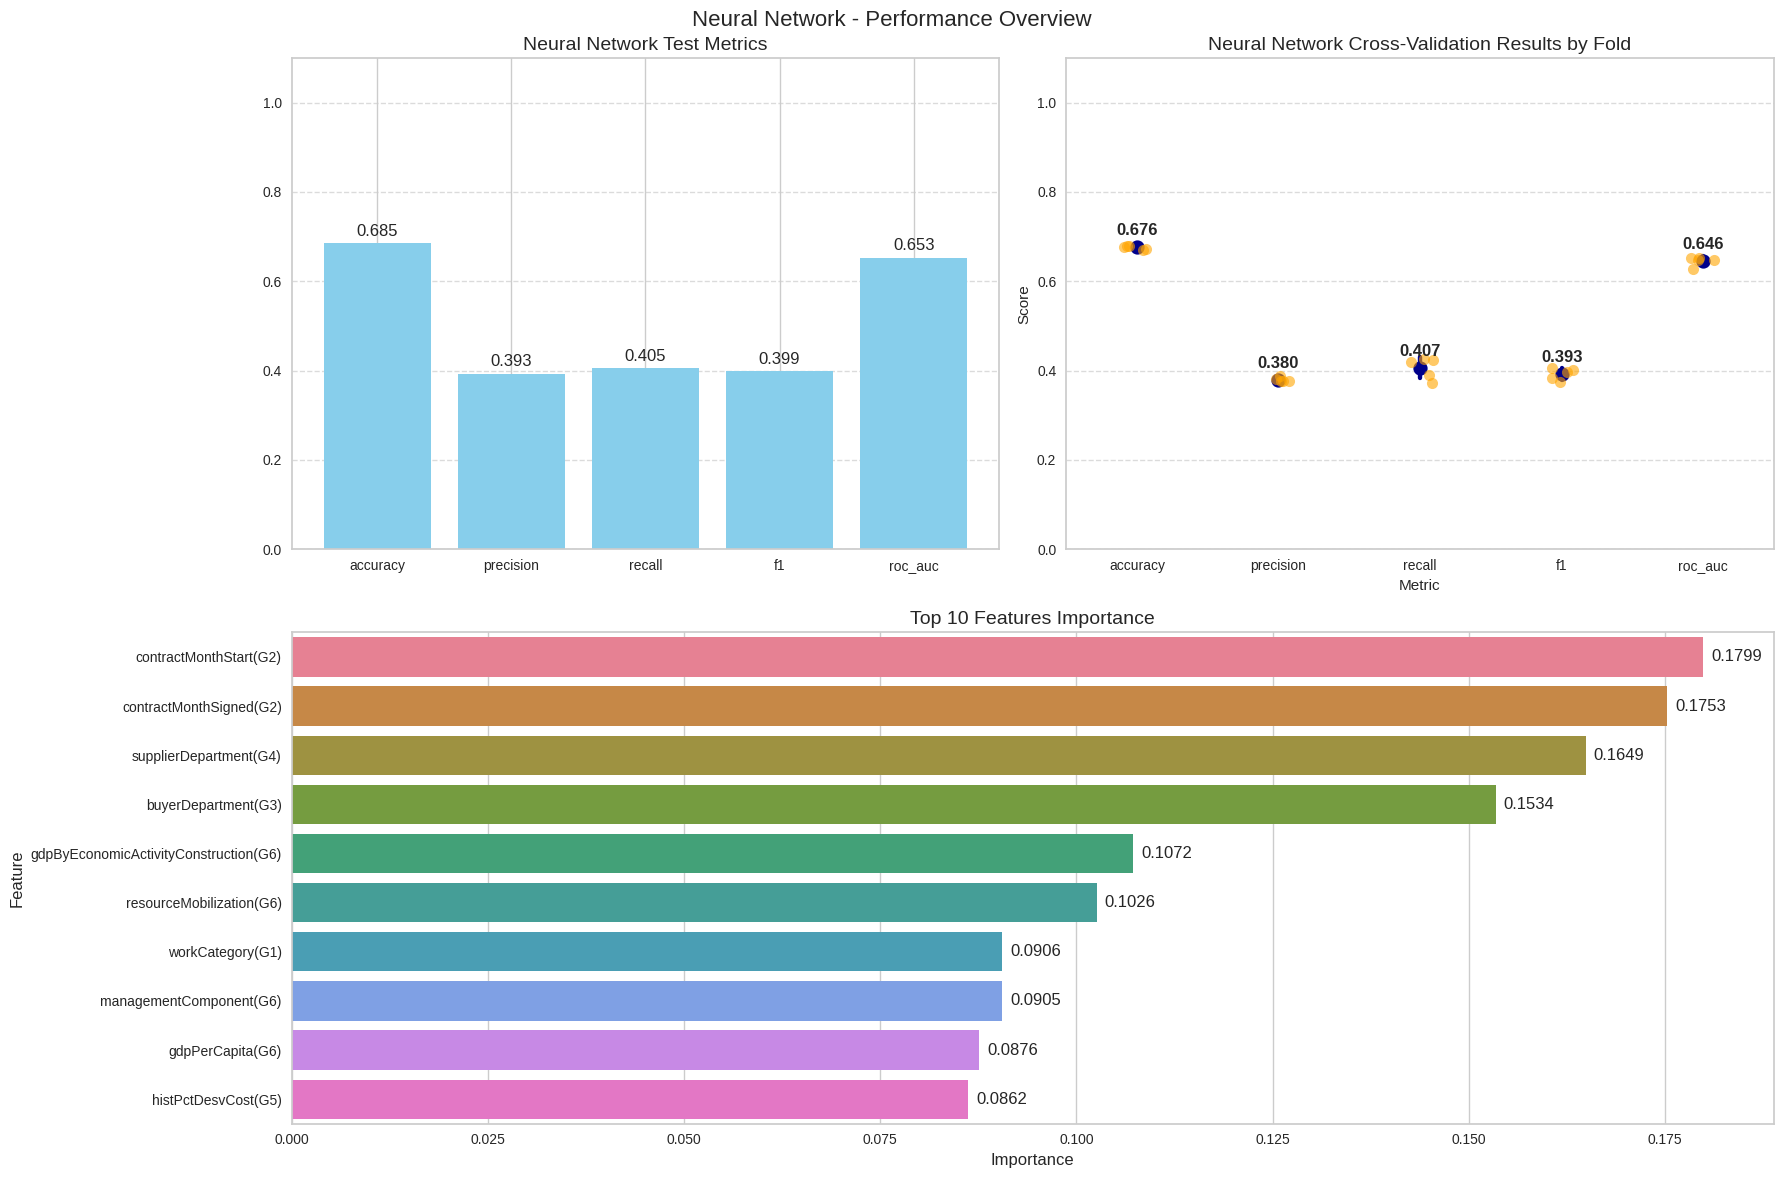

In [71]:
# Train Neural Network
nn_model_s4 = MLPClassifier(random_state=42, max_iter=1000)
nn_results_s4 = train_evaluate_model(
    classifier=nn_model_s4,
    X_train=X_train_s4,
    y_train=y_train_s4,
    X_test=X_test_s4,
    y_test=y_test_s4,
    numeric_columns=numericColumns,
    categorical_columns=categoricalColumns,
    model_name="Neural Network",
    stage='S4',
    use_smote=True,
    perform_cv=True,
    plot_results=True
)

### Consolidate results

In [72]:
# Consolidate scores of all models
lr_results_s4['metrics'].update({'Model': 'Logit'})
lr_results_s4['metrics'].update({'Stage': 'S4'})
lr_results_s4_df = pd.DataFrame(lr_results_s4['metrics'], index=[0])

ridge_results_s4['metrics'].update({'Model': 'Ridge'})
ridge_results_s4['metrics'].update({'Stage': 'S4'})
ridge_results_s4_df = pd.DataFrame(ridge_results_s4['metrics'], index=[0])

rf_results_s4['metrics'].update({'Model': 'Random Forest'})
rf_results_s4['metrics'].update({'Stage': 'S4'})
rf_results_s4_df = pd.DataFrame(rf_results_s4['metrics'], index=[0])

xgb_results_s4['metrics'].update({'Model': 'XGBoost'})
xgb_results_s4['metrics'].update({'Stage': 'S4'})
xgb_results_s4_df = pd.DataFrame(xgb_results_s4['metrics'], index=[0])

lgb_results_s4['metrics'].update({'Model': 'LightGBM'})
lgb_results_s4['metrics'].update({'Stage': 'S4'})
lgb_results_s4_df = pd.DataFrame(lgb_results_s4['metrics'], index=[0])

knn_results_s4['metrics'].update({'Model': 'KNN'})
knn_results_s4['metrics'].update({'Stage': 'S4'})
knn_results_s4_df = pd.DataFrame(knn_results_s4['metrics'], index=[0])

svc_results_s4['metrics'].update({'Model': 'SVC'})
svc_results_s4['metrics'].update({'Stage': 'S4'})
svc_results_s4_df = pd.DataFrame(svc_results_s4['metrics'], index=[0])

nn_results_s4['metrics'].update({'Model': 'Neural Network'})
nn_results_s4['metrics'].update({'Stage': 'S4'})
nn_results_s4_df = pd.DataFrame(nn_results_s4['metrics'], index=[0])

# consolidate all data frame
scores_df_s4 = pd.concat([lr_results_s4_df,
                       ridge_results_s4_df,
                       rf_results_s4_df,
                       xgb_results_s4_df,
                       lgb_results_s4_df,
                       knn_results_s4_df,
                       svc_results_s4_df,
                       nn_results_s4_df],
                      ignore_index=True)

# Calcular la media para las columnas numéricas
mean_values = scores_df_s4.select_dtypes(include=['number']).mean()
mean_row = pd.Series({'Stage': 'S4', 'Model': 'Mean'})
for col in mean_values.index:
    mean_row[col] = mean_values[col]

# Calcular la desviación estándar para las columnas numéricas
std_values = scores_df_s4.select_dtypes(include=['number']).std()
std_row = pd.Series({'Stage': 'S4', 'Model': 'Std'})
for col in std_values.index:
    std_row[col] = std_values[col]

# Añadir las filas al DataFrame
scores_df_s4 = pd.concat([scores_df_s4, pd.DataFrame([mean_row, std_row])], ignore_index=True)
print((scores_df_s4))

   accuracy  precision    recall        f1   roc_auc           Model Stage
0  0.639274   0.381982  0.646432  0.480207  0.704170           Logit    S4
1  0.637124   0.380240  0.647359  0.479081       NaN           Ridge    S4
2  0.753822   0.537279  0.323911  0.404163  0.738785   Random Forest    S4
3  0.750597   0.527174  0.314643  0.394080  0.723793         XGBoost    S4
4  0.755972   0.559462  0.250695  0.346240  0.729195        LightGBM    S4
5  0.618729   0.369839  0.680723  0.479282  0.687485             KNN    S4
6  0.656355   0.392397  0.607507  0.476814       NaN             SVC    S4
7  0.685141   0.392729  0.405468  0.398997  0.652829  Neural Network    S4
8  0.687127   0.442638  0.484592  0.432358  0.706043            Mean    S4
9  0.058108   0.082495  0.178057  0.052699  0.031946             Std    S4


In [73]:
pd.concat([scores_df_s1, scores_df_s2,scores_df_s3,scores_df_s4]).groupby(['Stage','Model']).mean().to_latex(index=True,
                  #formatters={"name": str.upper},
                  float_format="{:.4f}".format,)

'\\begin{tabular}{llrrrrr}\n\\toprule\n &  & accuracy & precision & recall & f1 & roc_auc \\\\\nStage & Model &  &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{10}{*}{S1} & KNN & 0.5852 & 0.3109 & 0.5009 & 0.3837 & 0.5755 \\\\\n & LightGBM & 0.7182 & 0.4040 & 0.1960 & 0.2640 & 0.6090 \\\\\n & Logit & 0.6012 & 0.3330 & 0.5454 & 0.4135 & 0.6164 \\\\\n & Mean & 0.6423 & 0.3466 & 0.3981 & 0.3540 & 0.5943 \\\\\n & Neural Network & 0.6217 & 0.3158 & 0.4008 & 0.3533 & 0.5608 \\\\\n & Random Forest & 0.6887 & 0.3629 & 0.2748 & 0.3128 & 0.6034 \\\\\n & Ridge & 0.5999 & 0.3311 & 0.5412 & 0.4108 & NaN \\\\\n & SVC & 0.6220 & 0.3360 & 0.4782 & 0.3947 & NaN \\\\\n & Std & 0.0521 & 0.0325 & 0.1404 & 0.0562 & 0.0215 \\\\\n & XGBoost & 0.7016 & 0.3791 & 0.2470 & 0.2991 & 0.6006 \\\\\n\\cline{1-7}\n\\multirow[t]{10}{*}{S2} & KNN & 0.5671 & 0.3189 & 0.5982 & 0.4160 & 0.6035 \\\\\n & LightGBM & 0.7426 & 0.5017 & 0.2048 & 0.2909 & 0.6854 \\\\\n & Logit & 0.6154 & 0.3636 & 0.6557 & 0.4678 & 0.6803 \\\\\n & Mea

In [1]:
pd.concat([scores_df_s1, scores_df_s2,scores_df_s3,scores_df_s4]).groupby(['Stage','Model']).mean()

NameError: name 'pd' is not defined